# Exercise Sheet 1 - CIFAR, MLP, Overfitting and Regularization

 * Deep Learning for Computer Vision – Winter Term 2025/26
 * Lecture by: Constantin Pape
 * Organizers: Anwai Archit, Sushmita Nair
 * Tutors: Azhar Akhmetova, Benjamin Eckhardt, Carolin Teuber, Luca Freckmann, Marei Freitag, Oleg Bakumenko, Sarah Muth
 * Due date: **Tuesday, Nov 11, before 10:00**


## Time required to solve this exercise sheet
**As you will train a large number of models on this exercise sheet, model training will require an increased amount of time. So we recommend to start working on this sheet early.**


## Topic

In this exercise sheet, you will:
- get to know a new dataset: CIFAR-10
- implement an MLP
- get more familiar with model fitting
- see overfitting
- implement early stopping
- explore hyperparameters and their influence
- vary the architecture to improve model performance

*We are looking forward to seeing your solutions! Have fun!*


## IMPORTANT SUBMISSION INSTRUCTIONS

- **You need to answer all questions in written form!**
- When you've completed the exercise, download the notebook and rename it to `<surname1>_<surname2>_<surname3>.ipynb`
- Only submit the Jupyter Notebook (.ipynb file). No other file is required.
    - Upload it on `Stud.IP` -> `Deep Learning for Computer Vision` -> `Files` -> `Submission of Homework 1`.
- Make only one submission of the exercise per group.
- The deadline is strict.
- You have to present the exercise in the tutorials. We have a high ratio of students to tutors, so please decide which team member presents which part beforehand

Implementation:
- Do not change the cells which are marked as `DO NOT CHANGE`, similarly write your solution into the cells marked with TODOs for the questions asked.

### How to work on the exercise?
You will need access to a machine with a GPU to properly work on the exercises. We recommend using [JupyterHPC](https://jupyter.hpc.gwdg.de/), which offers convenient access to a GPU. We have provided access to all the dependencies that we need preinstalled ([here](https://docs.google.com/document/d/1frgBvU9ZRcR7PkMqOuK5eTj5RphZBmjz_i6OgA1DVwE/edit?usp=sharing) are the initial steps and step-by-step guide to get started with working on JupyterHPC).

In addition, another recommended solution would be using [Kaggle](https://www.kaggle.com/), which also offers convenient access to a GPU and has all the dependencies that we need preinstalled ([here](https://gist.github.com/anwai98/444d3ff11c1365f2c610579d5df0830b) are the initial steps to work the Kaggle Notebooks). You can load this notebook on Kaggle via `File` -> `Import Notebook` -> `Browse Files` and `Import`.

## Introduction

In this task you will build a multi layer perceptron (MLP) model with PyTorch and perform training and prediction on the CIFAR dataset.

## Tutorials

Some python libraries are required to accomplish the tasks assigned in this homework. If you feel like you need to follow a tutorial before, feel free to do so:
- [PyTorch tutorial](https://pytorch.org/tutorials/)
- [Seaborn tutorial](https://seaborn.pydata.org/tutorial.html)

## Imports

Jupyter Notebook provides the possibility of using libraries, functions and variables globally. This means, once you import the libraries, functions, etc. you won't have to import them again in the next cell. However, if for any reason you end the session (crash, timeout, etc.), then you'll have to run this cell to have your libraries imported again. So, let's go ahead and import whatever we need in this homework assignment.

In [ ]:
import os
import time
import pathlib
import fastprogress

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

### GPU and CUDA checks

Let's perform some rudimentary system checks. Do we have a CUDA-capable device? Multiple? Is CuDNN active (huge speedups for some networks)

In [ ]:
torch.cuda.is_available(), torch.backends.cudnn.is_available(), torch.cuda.device_count()

(True, True, 1)

<details><summary>Additional Instructions for Kaggle Users</summary>

> NOTE: The suggestions below are for Kaggle users.

If you see now that now that there is no CUDA-capable device available, you have to activate the GPU.

Click the bottom-right corner menu `<` -> `Notebook` -> `Session options`-> `Accelerator` -> Select `GPU P100` as Hardware accelerator.

![image.png](attachment:image.png)

Now check the availability again (you would have to re-run the imports)

</details>

In [ ]:
# DO NOT CHANGE
def get_device(cuda_preference=True):
    """Gets pytorch device object. If cuda_preference=True and
        cuda is available on your system, returns a cuda device.

    Args:
        cuda_preference: bool, default True
            Set to true if you would like to get a cuda device

    Returns: pytorch device object
            Pytorch device
    """

    print(
        'cuda available:', torch.cuda.is_available(),
        '; cudnn available:', torch.backends.cudnn.is_available(),
        '; num devices:', torch.cuda.device_count()
    )

    use_cuda = False if not cuda_preference else torch.cuda.is_available()
    device = torch.device('cuda:0' if use_cuda else 'cpu')
    device_name = torch.cuda.get_device_name(device) if use_cuda else 'cpu'
    print('Using device', device_name)
    return device

In [ ]:
# DO NOT CHANGE
device = get_device()

# Get number of cpus to use for faster parallelized data loading
num_cpus = os.cpu_count()
print(num_cpus, 'CPUs available')

cuda available: True ; cudnn available: True ; num devices: 1
Using device Tesla T4
2 CPUs available


## Deep Learning with PyTorch

The process of training and evaluating a deep learning model begins with data loading. A dataset needs to be chosen on which the model should be trained. This data might need some preprocessing (like resizing or normalizing) of images. Splitting of the data in different sets is necessary. We need a set to train on, a set to validate the training progress and a set to test the model after training.

The next step is to **specify the model and its optimizer**, as well as the loss function. An important hyperparameter is the learning rate which influences how big the changes of the parameters should be after calculating the loss.

The model fitting is split into training and evaluation. In the training process the model does a forward pass which means the data is presented to the model and the model outputs a prediction. The loss compares the prediction with the ground truth. In the backward pass the gradient with regard to the parameter is calculated and the parameter are updated by the gradient step. In the evaluation process the loss is computed on the entire validation set. This is done to see how well the model operates on data for which the params were not optimized before in order to avoid overfitting. The model fitting process is repeated for N epochs which is another hyperparameter that needs to be chosen carefully.

After the training we evaluate the final model on the test set.

We'll go through the individual steps in the course of this notebook.

![image.png](attachment:image.png)

## Data Loading

## CIFAR dataset

This dataset contains natural images, and it is widely used by the machine learning community. It's really useful that you get accustomed with this dataset, as you'll come across it later to learn other concepts.

The first thing you should do when you begin to work with a data set that you have not used before is to play around with it to get a better understanding of its properties. Feel free to visualize the images to have a better understanding.

**Download** the CIFAR dataset using torchvision dataset classes.

In [ ]:
# DO NOT CHANGE
data_dir = os.path.expandvars("$PROJECT/data/Ex1")
if os.path.exists(data_dir):  # The location for the project directory.
    cifar = torchvision.datasets.CIFAR10(data_dir, train=True)
else:  # Otherwise, any miscellanous directory.
    data_dir = pathlib.Path("data/")
    cifar = torchvision.datasets.CIFAR10(data_dir, train=True, download=True)

100%|██████████| 170M/170M [00:03<00:00, 47.5MB/s]


Let's check the first sample to see what it looks like

<PIL.Image.Image image mode=RGB size=32x32 at 0x7A3DC05B9CD0>
Label index is 6, and Class label is frog


[]

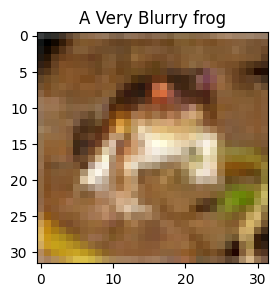

In [ ]:
X_sample, y_sample = cifar[0]
# TODO: display the label and the image
print(X_sample)
print(f'Label index is {y_sample}, and Class label is {cifar.classes[y_sample]}')

plt.figure(figsize=(3,3))
plt.imshow(X_sample)
plt.title(f'A Very Blurry {cifar.classes[y_sample]}')
plt.plot()

Look at the types of X and y.

In [ ]:
# TODO: display types
print(f' The Type of X is : {type(X_sample)} \t' ,
f'The Type of Y is {type(y_sample)}')

 The Type of X is : <class 'PIL.Image.Image'> 	 The Type of Y is <class 'int'>


How many data points are there in the dataset?

In [ ]:
# TODO: print out the length of the dataset
print(f'The length of the dataset is {len(cifar)}')
print(cifar)

The length of the dataset is 50000
Dataset CIFAR10
    Number of datapoints: 50000
    Root location: data
    Split: Train


## Loading data

### Preprocessing the Data

#### Transformation

We have seen above that the contents of the data set are of type [(PIL.Image.Image, Int)]. However, `pytorch` (the core library, not `torchvision`) is only equipped to work on Tensor objects. So we need to transform _PIL.Image.Image_ to _torch.Tensor_. Torchvision takes care of that for us. _transforms.ToTensor_ is a transformation operation that maps a _PIL.Image.Image_ to a torch tensor.

#### Normalization

Furthermore, we will **normalize** the data to zero-mean and unit-variance. _transforms.Normalize_ takes the mean and std-dev for each channel and rescales the data to zero-mean, unit-variance.

See https://pytorch.org/vision/stable/transforms.html for more information.

We can combine multiple transformations via _transforms.Compose_.

In [ ]:
def grab_data(data_dir, num_cpus=1, download=False):
    """Downloads CIFAR10 train and test set, stores them on disk, computes mean
        and standard deviation per channel of trainset, normalizes the train set
        accordingly.

    Args:
        data_dir (str): Directory to store data
        num_cpus (int, optional): Number of cpus that should be used to
            preprocess data. Defaults to 1.
        download (bool): Whether to download the CIFAR10 dataset or not.

    Returns:
        CIFAR10, CIFAR10, float, float: Returns trainset and testset as
            torchvision CIFAR10 dataset objects. Returns mean and standard
            deviation used for normalization.
    """
    trainset = torchvision.datasets.CIFAR10(
        data_dir, train=True, download=download, transform=torchvision.transforms.ToTensor()
    )

    # Get normalization transform
    num_samples = trainset.data.shape[0]
    trainloader = torch.utils.data.DataLoader(
        trainset, batch_size=num_samples, num_workers=num_cpus
    )
    imgs, _ = next(iter(trainloader))
    dataset_mean = torch.mean(imgs, dim=(0,2,3))
    dataset_std = torch.std(imgs, dim=(0,2,3))

    normalized_transform = torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(dataset_mean, dataset_std)
    ])

    # Load again, now normalized
    trainset = torchvision.datasets.CIFAR10(
        data_dir, download=download, train=True, transform=normalized_transform
    )

    # Apply the same transform, computed from the train-set, to the test-set
    # so both have a similar distribution. We do not normalize the test-set directly,
    # since we are not allowed to perform any computations with it. (We only use it
    # for reporting results in the very end)
    testset = torchvision.datasets.CIFAR10(
        data_dir, download=download, train=False, transform=normalized_transform
    )

    return trainset, testset, dataset_mean, dataset_std

#### Training, Validation and Test Sets

For the correct ftting of a neural network, we need three dataset components: one for training, one for validation in the training process, and the last one for testing the results of the training on unseen data.

Note that you should not use the test set in any part of your training and model selection procedure. It should only be used for showing the final results.

We first need to **load** the datasets (above we did that already to calculate the normalization values. Then, we load them and **apply the normalization transform**)

We also need to **split** the train dataset into two sets, one for training and one for validation. While the training set needs to be quite large, the validation set can be relatively small. Take 10% of the dataset as validation set. Assign samples _randomly_ to the training and validation set, using a fixed seed to ensure reproducibility.

In [ ]:
def generate_train_val_data_split(trainset, split_seed=42, val_frac=0.2):
    """Splits train dataset into train and validation dataset.

    Args:
        trainset (CIFAR10): CIFAR10 trainset object
        split_seed (int, optional): Seed used to randomly assign data
            points to the validation set. Defaults to 42.
        val_frac (float, optional): Fraction of training set that should be
            split into validation set. Defaults to 0.2.

    Returns:
        CIFAR10, CIFAR10: CIFAR10 trainset and validation set.
    """
    num_val_samples = np.ceil(val_frac * trainset.data.shape[0]).astype(int)
    num_train_samples = trainset.data.shape[0] - num_val_samples
    trainset, valset = torch.utils.data.random_split(
        trainset, (num_train_samples, num_val_samples), generator=torch.Generator().manual_seed(split_seed)
    )
    return trainset, valset

To load the data for model training, we need to define **dataloaders**. A dataloader represents a Python iterable over a dataset and draws mini batches with random samples. Obseve below that we have a default number for batch size, and we shuffle the samples in batches.

In [ ]:
def init_data_loaders(trainset, valset, testset, batch_size=1024, num_cpus=1):
    """Initialize train, validation and test data loader.

    Args:
        trainset (CIFAR10): Training set torchvision dataset object.
        valset (CIFAR10): Validation set torchvision dataset object.
        testset (CIFAR10): Test set torchvision dataset object.
        batch_size (int, optional): Batchsize that should be generated by
            pytorch dataloader object. Defaults to 1024.
        num_cpus (int, optional): Number of CPUs to use when iterating over
            the data loader. More is faster. Defaults to 1.

    Returns:
        DataLoader, DataLoader, DataLoader: Returns pytorch DataLoader objects
            for training, validation and testing.
    """
    trainloader = torch.utils.data.DataLoader(
        trainset, batch_size=batch_size, shuffle=True, num_workers=num_cpus
    )
    valloader = torch.utils.data.DataLoader(
        valset, batch_size=batch_size, shuffle=True, num_workers=num_cpus
    )
    testloader = torch.utils.data.DataLoader(
        testset, batch_size=batch_size, shuffle=True, num_workers=num_cpus
    )

    return trainloader, valloader, testloader

#### TODO
- Load the CIFAR 10 train and test data set using the functions defined above
- Generate a validation set from 20% of the training set samples. *Remember:* Keep the seed for the validation set generation fixed for reproducibility.
- Generate torch data loaders for the train, validation and test data set splits. Use a batch size of 1024.

*Hint:* we will use the mean and standard deviation returned by ```grab_data``` later

In [ ]:
data_dir = os.path.expandvars("$PROJECT/data/Ex1")

####################
## YOUR CODE HERE ##
####################

trainset, testset, dataset_mean, dataset_std = grab_data("./data", num_cpus=2, download=True)
trainset, valset = generate_train_val_data_split(trainset)
trainloader, valloader, testloader = init_data_loaders(trainset, valset, testset)

print("Train size:", len(trainset))
print("Test size :", len(testset))
print("Mean shape:", dataset_mean.shape, "->", dataset_mean.tolist())
print("Std  shape:", dataset_std.shape,  "->", dataset_std.tolist())

Train size: 40000
Test size : 10000
Mean shape: torch.Size([3]) -> [0.491400808095932, 0.48215898871421814, 0.44653093814849854]
Std  shape: torch.Size([3]) -> [0.24703224003314972, 0.24348513782024384, 0.26158785820007324]


Let's have a look at the dataset.

#### TODO
- Print all the class names
- Plot 16 images randomly drawn from the training set with their according class label

*Hint:* Since you normalized the dataset before, you have to undo that operation for plotting

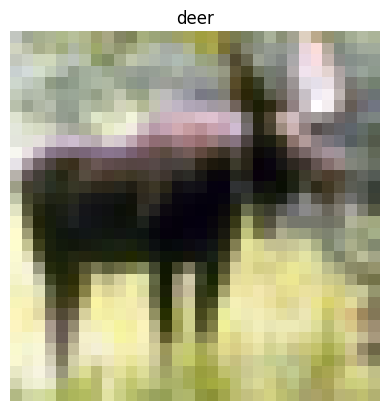

In [ ]:
def imshow(img, mean, std, title = None ):
    """Undo normalization using mean and standard deviation and show image.

    Args:
        img (torch.Tensor): Image to show
        mean (np.array shape (3,)): Vector of means per channel used to
            normalize the dataset.
        std (np.array shape (3,)): Vector of standard deviations per channel
            used to normalize the dataset.
    """
    # Define function to plot
    ####################
    ## YOUR CODE HERE ##
    ####################
    mean = mean.view(3,1,1) # Permutation to Match the Dimension of the Img
    std = std.view(3,1,1)

    if img.dim() == 4:
        img = img[0]

    img = img.detach()
    img = (img * std) + mean
    npimg = img.numpy()

    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    if title is not None:
        plt.title(title)
    plt.show()


# single image Test
X , y = next(iter(trainloader))
imshow(X[0], dataset_mean, dataset_std, cifar.classes[y[0]])

['airplane', 'bird', 'frog', 'horse', 'bird', 'airplane', 'bird', 'airplane', 'cat', 'ship', 'deer', 'truck', 'bird', 'airplane', 'truck', 'airplane']


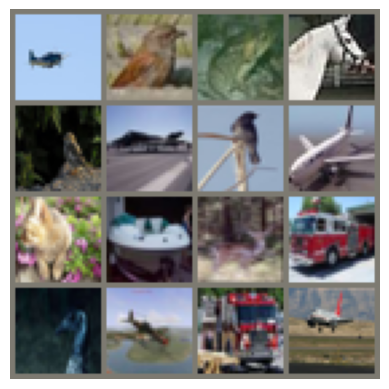

In [ ]:
# Create actual plot and print the class names

####################
## YOUR CODE HERE ##
####################
X , y = next(iter(trainloader))
classes = cifar.classes
names = [classes[i] for i in y[:16]]
print(names)

from torchvision.utils import make_grid
grid = make_grid(X[:16], nrow=4, padding=2)
imshow(grid, dataset_mean, dataset_std)

# Hint: Use `torchvision.utils.make_grid`.

Now that you know what CIFAR10 looks like, you can guess what the task for this dataset is: classification in natural images

## Training, evaluation and plotting functions

Here, we provide examples of training, evaluation and plotting functions. Some parts are still missing. You can ignore this for the time being and move to the next section "**MLP Model**". You will implement the missing parts of these functions when required in the next sections.

In [ ]:
def accuracy(correct, total):
    """Compute accuracy as percentage.

    Args:
        correct (int): Number of samples correctly predicted.
        total (int): Total number of samples

    Returns:
        float: Accuracy
    """
    return float(correct)/total


def train(dataloader, optimizer, model, loss_fn, device, master_bar):
    """Run one training epoch.

    Args:
        dataloader (DataLoader): Torch DataLoader object to load data
        optimizer: Torch optimizer object
        model (nn.Module): Torch model to train
        loss_fn: Torch loss function
        device (torch.device): Torch device to use for training
        master_bar (fastprogress.master_bar): Will be iterated over for each
            epoch to draw batches and display training progress

    Returns:
        float, float: Mean loss of this epoch, fraction of correct predictions
            on training set (accuracy)
    """
    epoch_loss = []
    epoch_correct, epoch_total = 0, 0

    for x, y in fastprogress.progress_bar(dataloader, parent=master_bar):
        optimizer.zero_grad()
        model.train()

        # Forward pass
        y_pred = model(x.to(device))

        # For calculating the accuracy, save the number of correctly classified
        # images and the total number
        epoch_correct += sum(y.to(device) == y_pred.argmax(dim=1))
        epoch_total += len(y)

        # Compute loss
        loss = loss_fn(y_pred, y.to(device))

        # Backward pass
        loss.backward()
        optimizer.step()

        # For plotting the train loss, save it for each sample
        epoch_loss.append(loss.item())

    # Return the mean loss and the accuracy of this epoch
    return np.mean(epoch_loss), accuracy(epoch_correct, epoch_total)


def validate(dataloader, model, loss_fn, device, master_bar):
    """Compute loss, accuracy and confusion matrix on validation set.

    Args:
        dataloader (DataLoader): Torch DataLoader object to load data
        model (nn.Module): Torch model to train
        loss_fn: Torch loss function
        device (torch.device): Torch device to use for training
        master_bar (fastprogress.master_bar): Will be iterated over to draw
            batches and show validation progress

    Returns:
        float, float, torch.Tensor shape (10,10): Mean loss on validation set,
            fraction of correct predictions on validation set (accuracy)
    """
    epoch_loss = []
    epoch_correct, epoch_total = 0, 0
    confusion_matrix = torch.zeros(10, 10)

    model.eval()
    with torch.no_grad():
        for x, y in fastprogress.progress_bar(dataloader, parent=master_bar):
            # make a prediction on validation set
            y_pred = model(x.to(device))

            # For calculating the accuracy, save the number of correctly
            # classified images and the total number
            epoch_correct += sum(y.to(device) == y_pred.argmax(dim=1))
            epoch_total += len(y)

            # Fill confusion matrix
            for (y_true, y_p) in zip(y, y_pred.argmax(dim=1)):
                confusion_matrix[int(y_true), int(y_p)] +=1

            # Compute loss
            loss = loss_fn(y_pred, y.to(device))

            # For plotting the train loss, save it for each sample
            epoch_loss.append(loss.item())

    # Return the mean loss, the accuracy and the confusion matrix
    return np.mean(epoch_loss), accuracy(epoch_correct, epoch_total), confusion_matrix


def run_training(
    model, optimizer, loss_function, device, num_epochs, train_dataloader, val_dataloader, early_stopper=None, verbose=False
):
    """Run model training.

    Args:
        model (nn.Module): Torch model to train
        optimizer: Torch optimizer object
        loss_fn: Torch loss function for training
        device (torch.device): Torch device to use for training
        num_epochs (int): Max. number of epochs to train
        train_dataloader (DataLoader): Torch DataLoader object to load the
            training data
        val_dataloader (DataLoader): Torch DataLoader object to load the
            validation data
        early_stopper (EarlyStopper, optional): If passed, model will be trained
            with early stopping. Defaults to None.
        verbose (bool, optional): Print information about model training.
            Defaults to False.

    Returns:
        list, list, list, list, torch.Tensor shape (10,10): Return list of train
            losses, validation losses, train accuracies, validation accuracies
            per epoch and the confusion matrix evaluated in the last epoch.
    """
    start_time = time.time()
    master_bar = fastprogress.master_bar(range(num_epochs))
    train_losses, val_losses, train_accs, val_accs = [],[],[],[]

    for epoch in master_bar:
        # Train the model
        epoch_train_loss, epoch_train_acc = train(
            train_dataloader, optimizer, model, loss_function, device, master_bar
        )
        # Validate the model
        epoch_val_loss, epoch_val_acc, confusion_matrix = validate(
            val_dataloader, model, loss_function, device, master_bar
        )

        # Save loss and acc for plotting
        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
        train_accs.append(epoch_train_acc)
        val_accs.append(epoch_val_acc)

        if verbose:
            master_bar.write(f'Train loss: {epoch_train_loss:.2f}, val loss: {epoch_val_loss:.2f}, train acc: {epoch_train_acc:.3f}, val acc {epoch_val_acc:.3f}')

        if early_stopper:
            ####################
            ## YOUR CODE HERE ##
            ####################
            early_stopper.update(epoch_val_acc,model) # Updating the Counter and Saving

            if early_stopper.early_stop_trigger == True :  # Loading Best Model Weights before exiting the Training Loop
                early_stopper.load_checkpoint(model)
                break # Breaking out of Loop

            # raise NotImplementedError # Comment out this keyword after your implementation

            # END OF YOUR CODE #

    time_elapsed = np.round(time.time() - start_time, 0).astype(int)
    print(f'Finished training after {time_elapsed} seconds.')
    return train_losses, val_losses, train_accs, val_accs, confusion_matrix


def plot(
    title, label, train_results, val_results, yscale='linear', save_path=None, extra_pt=None, extra_pt_label=None
):
    """Plot learning curves.

    Args:
        title (str): Title of plot
        label (str): x-axis label
        train_results (list): Results vector of training of length of number
            of epochs trained. Could be loss or accuracy.
        val_results (list): Results vector of validation of length of number
            of epochs. Could be loss or accuracy.
        yscale (str, optional): Matplotlib.pyplot.yscale parameter.
            Defaults to 'linear'.
        save_path (str, optional): If passed, figure will be saved at this path.
            Defaults to None.
        extra_pt (tuple, optional): Tuple of length 2, defining x and y coordinate
            of where an additional black dot will be plotted. Defaults to None.
        extra_pt_label (str, optional): Legend label of extra point. Defaults to None.
    """

    epoch_array = np.arange(len(train_results)) + 1
    train_label, val_label = "Training "+label.lower(), "Validation "+label.lower()

    sns.set(style='ticks')

    plt.plot(epoch_array, train_results, epoch_array, val_results, linestyle='dashed', marker='o')
    legend = ['Train results', 'Validation results']

    if extra_pt:
        ####################
        ## YOUR CODE HERE ##
        ####################
        plt.scatter(extra_pt[0] +0.001, extra_pt[1] +0.001, color='black', marker = '+', zorder = 5) # The 0.001 is for an Offset
        if extra_pt_label:
            legend.append(extra_pt_label)


        # raise NotImplementedError # Comment out this keyword after your implementation

        # END OF YOUR CODE #

    plt.legend(legend)
    plt.xlabel('Epoch')
    plt.ylabel(label)
    plt.yscale(yscale)
    plt.title(title)

    sns.despine(trim=True, offset=5)
    plt.title(title, fontsize=15)
    if save_path:
        plt.savefig(str(save_path), bbox_inches='tight')
    plt.show()

## MLP model

#### TODO
- Define an MLP model implementing all the functionality indicated by the parameters and the docstrings
- There should be a non-linearity after the input layer and in the hidden layers, i.e. in all layers that map to hidden units, but not in the final (linear) layer that creates the outputs

*Hint*: As CIFAR 10 contains color images, amongst other dimensions you want to flatten the color channel dimension, too.

In [ ]:
class MLP(nn.Module):
    """Multi layer perceptron torch model."""
    def __init__(
        self, img_width = 32, num_in_channels = 3 , num_classes = 10, num_hidden_units=30, num_hidden_layers=1, act_fn=None
    ):
        """Initialize model.

        Args:
            img_width (int): Width of images
            num_in_channels (int): Number of input channels of images
            num_classes (int): Number of classes to predict
            num_hidden_units (int, optional): Number of hidden units per layer.
                Defaults to 30.
            num_hidden_layers (int, optional): Number of hidden layers. Total
                number of layers will be num_hidden_layers + 2. Defaults to 1.
            act_fn (nn activation function, optional): Activation function
                to use after the first and all the hidden layers. If None, use
                nn.ReLU(). Defaults to None.
        """
        ####################
        ## YOUR CODE HERE ##
        ####################
        super().__init__()

        self.img_width = img_width
        self.num_in_channels = num_in_channels
        self.num_classes = num_classes
        self.num_hidden_units = num_hidden_units
        self.num_hidden_layers = num_hidden_layers
        self.act_fn = act_fn or nn.ReLU()

        # Flattened Image Dimensions
        input_dim = img_width * img_width * num_in_channels
        # First Input Layer
        self.fc_in = nn.Linear(input_dim, num_hidden_units)
        # Hidden Layers
        self.hidden_fc = nn.ModuleList([nn.Linear(num_hidden_units, num_hidden_units) for i in range(num_hidden_layers)])
        # Output Layer
        self.fc_out = nn.Linear(num_hidden_units, num_classes)

    def forward(self, x):
        """Compute model predictions.

        Args:
            x (torch.Tensor, shape (batchsize, num_channels, x, y)): Tensor of
                batch of input images

        Returns:
            torch.Tensor, shape (batchsize, num_classes): Tensor of model
                predictions
        """
        ####################
        ## YOUR CODE HERE ##
        ####################
        # (Batch_dim, Num_channels, Height, Width) -> (Batch_Dim , input_dim)
        x = x.view(x.size(0),-1)
        # First Layer Input
        x = self.fc_in(x)
        # Activation
        x = self.act_fn(x)

        # Hidden Layers
        for layer in self.hidden_fc:
            x = layer(x)
            x = self.act_fn(x)

        # Output
        x = self.fc_out(x) # No Activation Because of CrossEntropyLoss Loss Funcition
        return x

## Model training: learning rate

One of the most important hyperparameters is the learning rate. If we set it incorrectly, our model might not train at all, take very long time to train, or lead to suboptimal performance. Thus, we should make sure to set it appropriately.

So with what learning rate should we start? Usually, you would start setting a very high learning rate, e.g. ```lr = 1e0``` and then decrease it by a factor of ten until the model starts to converge. Since we might have to try multiple values here, it is sufficient to train only a few iterations to see if the model trains at all. As soon as we find a learning rate that works, we train for more epochs to get a well performing model.

For optimization, we use the commonly used Adam optimizer (not SGD), since it behaves very robustly and is easy to use.

#### TODO:
- Instantiate a MLP model with one hidden layer and ReLU activation function
- Train the model for 10 epochs
- Use the Adam optimizer
- Start with a learning rate of $10^0$, then decrease the learning rate logarithmically, i.e. by a factor of 10, until your model starts to train
- Plot the training curves of the loss and the accuracies as in exercise 1. Use the functions defined above.

*Hints:*

**This is an example of a model that does not train sufficiently:** *(Why?)*

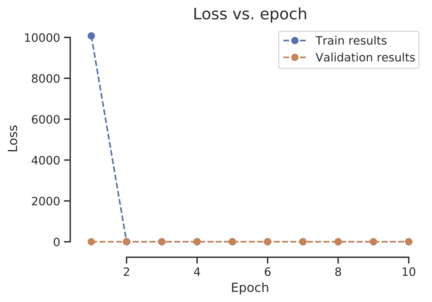

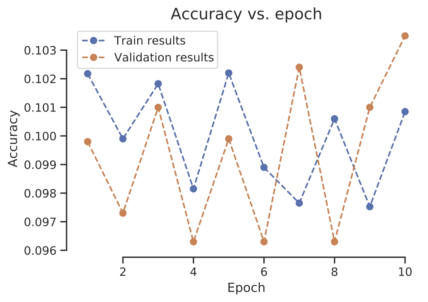

**This is an example of a model that does train:** *(Why?)*

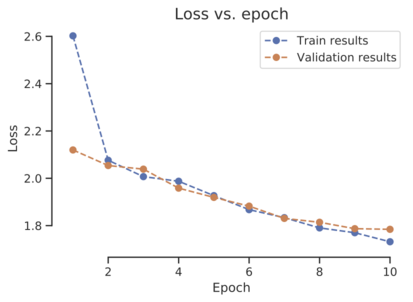

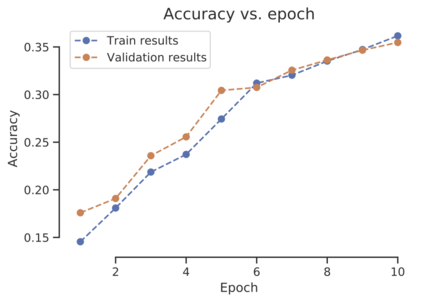

Finished training after 103 seconds.


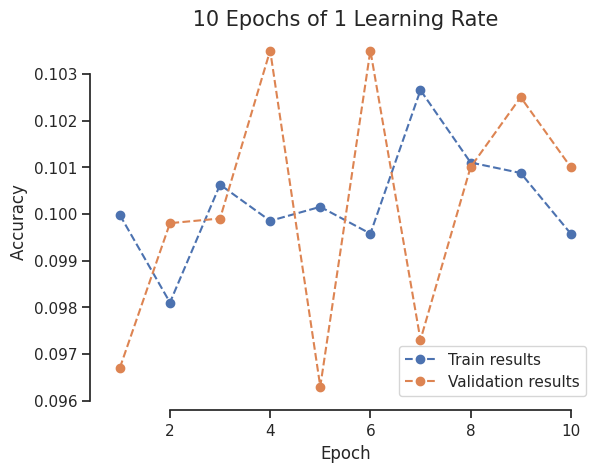

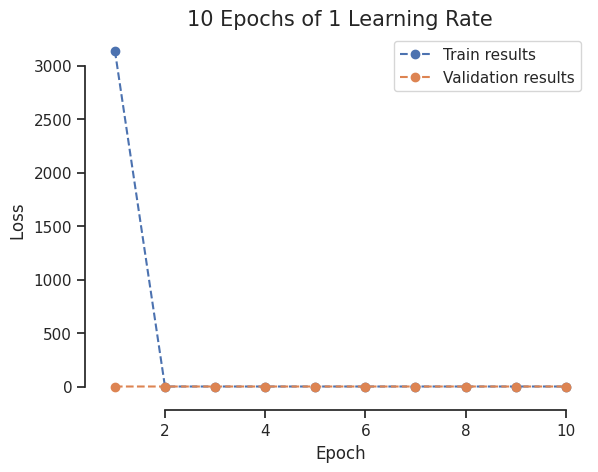

Finished training after 107 seconds.


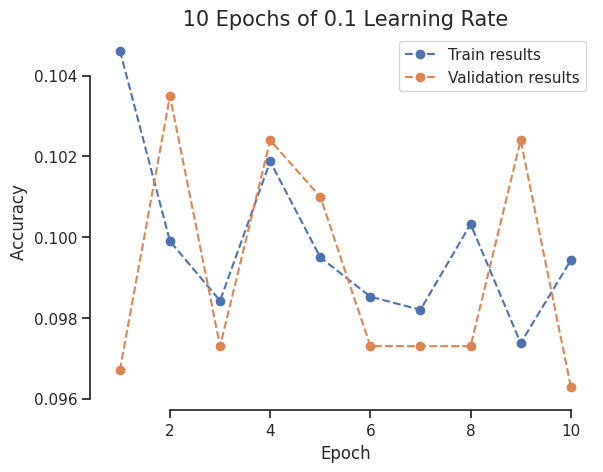

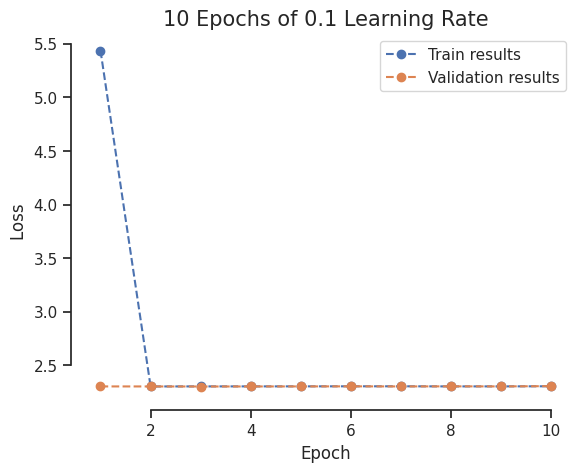

Finished training after 104 seconds.


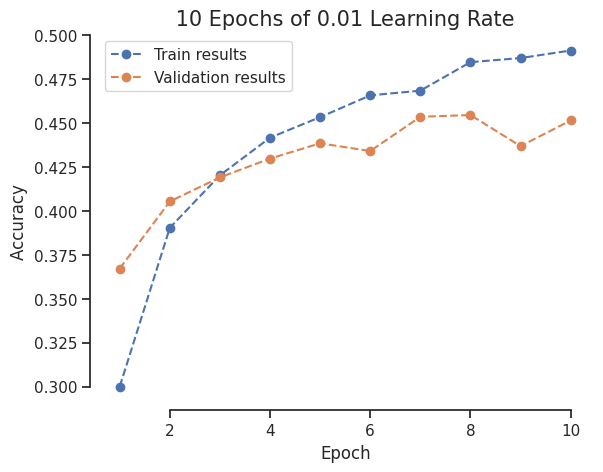

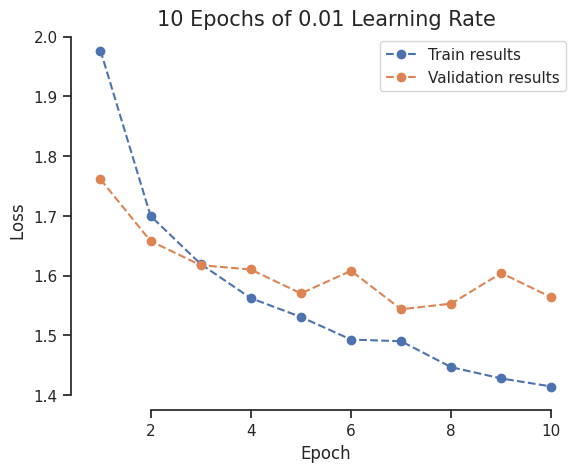

Finished training after 103 seconds.


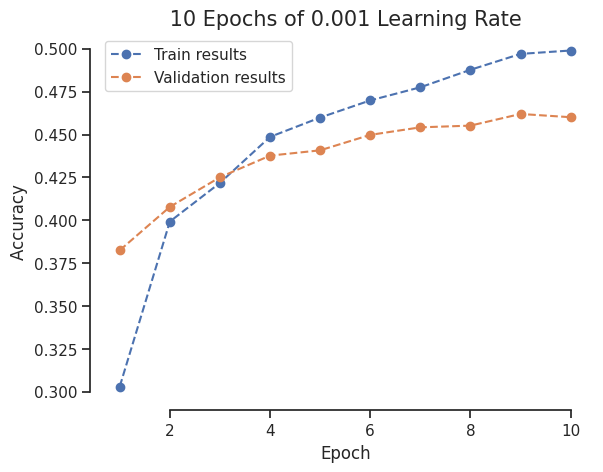

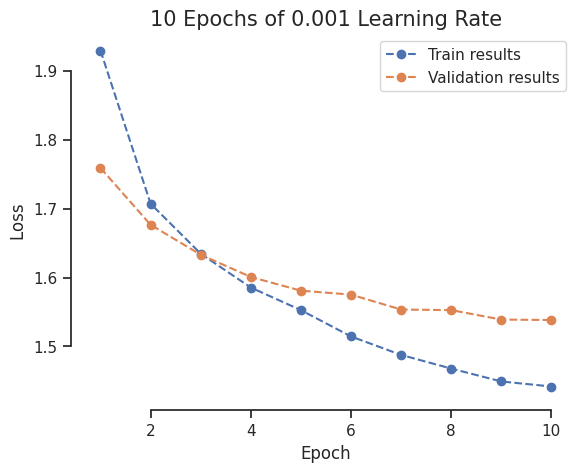

Finished training after 103 seconds.


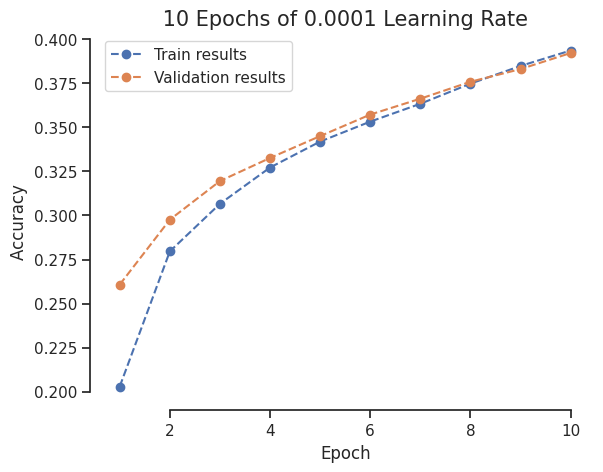

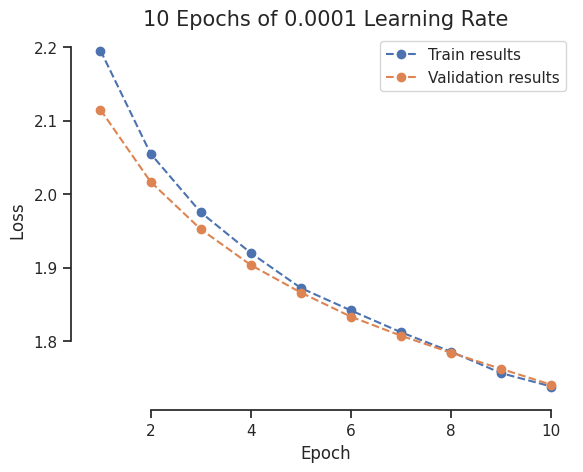

Finished training after 103 seconds.


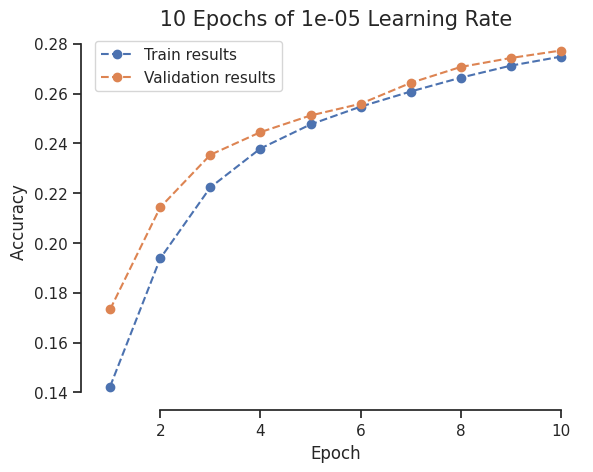

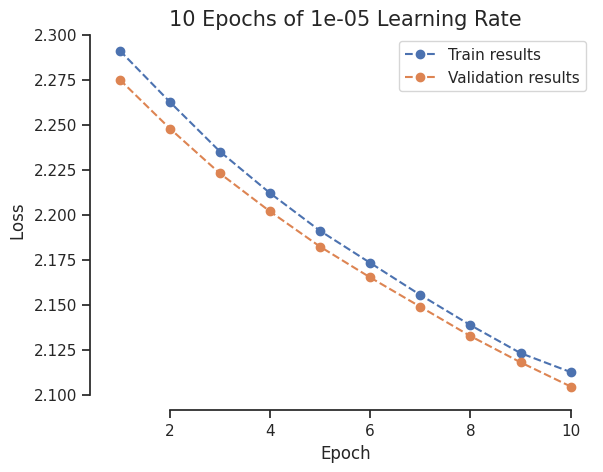

In [ ]:
####################
## YOUR CODE HERE ##
####################
learning_rates = [1,1e-1,1e-2,1e-3, 1e-4, 1e-5]
for lr in learning_rates:
    model = MLP().to(device)
    optimizer = optim.Adam(lr= lr, params = model.parameters())
    loss_function = nn.CrossEntropyLoss().to(device)
    train_losses, val_losses, train_accs, val_accs, confusion_matrix = run_training(
        model=model,
        optimizer=optimizer,
        loss_function=loss_function,
        device=device,
        num_epochs=10,
        train_dataloader=trainloader,
        val_dataloader=valloader,
        verbose=True )
    plot(label = 'Accuracy ' , train_results = train_accs, val_results = val_accs , title = f' 10 Epochs of {lr} Learning Rate ')
    plot(label = 'Loss ' , train_results = train_losses, val_results = val_losses , title = f'10 Epochs of {lr} Learning Rate')
    print(' ')
    print(' ')

Has your model already converged, i.e. reached the highest accuracy on the validation set? Probably not. So here are your TODOs:

#### TODO:
- Train the model for 100 epochs (this might take approx. 30 min depending on your GPU)

#### TODO from now on, for all subsequent tasks:
- Print the overall best value and the epoch at which it occurred of:
    - val loss and
    - val accuracy

ℹ️ The Best Learning Rate found for on training for 10 Epochs is  <mark style="background:#A6402D">**0.001**</mark>





In [ ]:
####################
## YOUR CODE HERE ##
####################
model = MLP().to(device)
optimizer = optim.Adam(lr= 0.001, params = model.parameters())
loss_function = nn.CrossEntropyLoss().to(device)
train_losses, val_losses, train_accs, val_accs, confusion_matrix = run_training(
    model=model,
    optimizer=optimizer,
    loss_function=loss_function,
    device=device,
    num_epochs=100,
    train_dataloader=trainloader,
    val_dataloader=valloader,
    verbose=True )

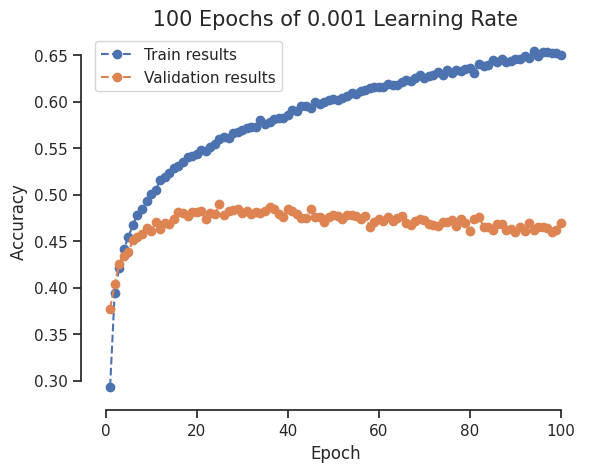

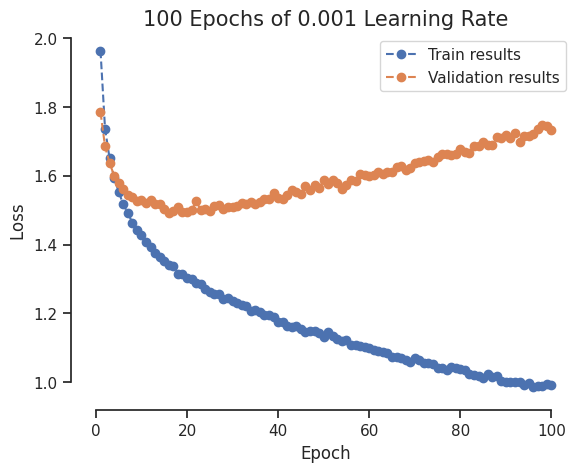

In [ ]:
plot(label = 'Accuracy ' , train_results = train_accs, val_results = val_accs , title = f' 100 Epochs of {0.001} Learning Rate ')
plot(label = 'Loss ' , train_results = train_losses, val_results = val_losses , title = f'100 Epochs of {0.001} Learning Rate')

Let's have a look at those training curves! Here are some questions for you.

#### TODO:
Answer the following questions in written form, as they are really crucial for the rest of this course.

1. Does the training loss decrease after each epoch? Why does it? // Why does it not?
1. Does the validation loss decrease after each epoch? Why does it? // Why does it not? (For your answer to be sufficient, you should describe fluctuations and discuss the minimum of the curves.)
1. Do the training and validation accuracy increase after each epoch? Why? // Why not?
1. Are the epochs at which you got the best validation loss and the best validation accuracy the same?
1. (Optional): Do you have any ideas why not?
1. At which epoch was your model best? I.e. if you had saved your model after each training epoch, which one would you use to make predictions to unseen samples (e.g. from the test set)? Why? (For your answer to be sufficient: Also discuss what this means in terms of overfitting)

#### Your answers:
1. The training loss decreases until the last epoch, because the model is learning the training data.
2. The validation loss decreases until a certain epoch, where the minimum of the curve is around 1.5 at around epoch 20, after that the losses curve trends upwards as it is increasing now, as the model is overfitting to the training data.
3. The training accuracy keeps increasing as the epochs increase, but the validation accuracy doesn't increase after around epoch 20 (it plateaus with a slight decline). That's a classic sign of overfitting, as the model is more or less memorizing the labels of the training but can't generalize to new unseen data.
4. <u> Yes they are  the same </u>
5. As the difference between the predicted labels and the true labels decrease the loss decreases, that means more correct predictions lead to less loss and higher accuracy
6. <u> Around epoch 20as the Validation loss was at its minimum and the accuracy was at its highest, the model was able to generalize well to new unseen data, and the model had not overfit yet. But, beyond this epoch the modelwas overfitting to the training data, and performing worse on the Validation set </u>

## Save and restore model checkpoints

Training that model for 100 epochs took quite a bit of time, right? Wouldn't it be a pity if it would get deleted out of memory, e.g. because your Colab session terminates (this can even happen automatically)? We would have to train it again to make predictions! To prevent this, we would like to save a check-point of the already optimized model's weights to disk. Then, we could just load our model weights at any time and use our model again without retraining. As you will see in a bit, this will be very handy for early stopping, too!

#### TODO:
- Save a checkpoint of the `model` trained above (i.e. the model's parameters) to disk
- Initialize a new model, `model2` with the same architecture as used for the `model` you stored. Do *not* train `model2`.
- Compute `model2`'s validation set accuracy. *Hint:* You can use the validation function from above. As a parameter, you would have to set `master_bar=None` since there is no progress bar for epochs in this setting.
- Now, overwrite the initialized, untrained weights of `model2` with the weights you saved into the checkpoint of `model`.
- Evaluate `model2`'s validation set accuracy again. It should be of the exact same value as `model`'s validation set accuracy.

*Hints:*
- Read https://pytorch.org/tutorials/beginner/saving_loading_models.html
- Use `model.state_dict()`

In [ ]:
####################
## YOUR CODE HERE ##
####################
# Feel free to add more cells here.
state_dictionary = model.state_dict()
torch.save(model.state_dict(), "model_state.pth")
model2 = MLP()

model2.load_state_dict(torch.load('/kaggle/working/model_state.pth'))

<All keys matched successfully>

In [ ]:
# Testing the Validation Accuracy of the Loaded Model
model2.to(device)
epoch_val_loss, epoch_val_acc, confusion_matrix = validate(
            valloader, model2, loss_function, device, master_bar=None
        )
# Printing the Values
print(f'Validation Accuracy is : {epoch_val_acc},\t Validation Loss is :  {epoch_val_loss}')

Validation Accuracy is : 0.4689,	 Validation Loss is :  1.7366276144981385


## Early Stopping

So the model you ended up with after 100 epochs was not the best one. That has two implications for us: (1) We would not have had to train for that many epochs and could have saved some computing time. (2) We do not have the best model to apply our model to make actual predictions for unseen samples. If we would constantly assess our model's validation performance during training, we could stop optimization as soon as our model's performance does not increase anymore. This is called *early stopping*.


#### TODO:
- Implement the `EarlyStopper` class below
- Modify `def run_training(...)` above such that it updates the `EarlyStopper` after each training epoch. Stop training as soon as the validation accuracy did not increase anymore. Then, load the model checkpoint of the previous epoch (i.e. your best model)

In [ ]:
class EarlyStopper:
    """Early stops the training if validation accuracy does not increase after a
    given patience. Saves and loads model checkpoints.
    """
    def __init__(self, verbose=False, path='checkpoint.pt', patience=1):
        """Initialization.

        Args:
            verbose (bool, optional): Print additional information. Defaults to False.
            path (str, optional): Path where checkpoints should be saved.
                Defaults to 'checkpoint.pt'.
            patience (int, optional): Number of epochs to wait for increasing
                accuracy. If accuracy does not increase, stop training early.
                Defaults to 1.
        """
        ####################
        ## YOUR CODE HERE ##
        ####################
        self.verbose = verbose
        self.path = path
        self.patience = patience
        self.counter = 0
        self.early_stop_trigger = False
        self.best_acc = -np.inf

    @property
    def early_stop(self):
        """True if early stopping criterion is reached.

        Returns:
            [bool]: True if early stopping criterion is reached.
        """
        ####################
        ## YOUR CODE HERE ##
        ####################
        return  self.early_stop_trigger

    def update(self, val_acc, model):
        """Call after each epoch of model training to update early stopper object.

        Args:
            val_acc (float): Accuracy on validation set
            model (nn.Module): torch model that is trained
        """
        ####################
        ## YOUR CODE HERE ##
        ####################
        if val_acc > self.best_acc : # For less strict Version use less or equal to reset patience on Ties
            self.best_acc = val_acc
            self.counter = 0
            if self.verbose == True :
                print(f' New Best Accuracy Reached: {val_acc} ')
            self.save_checkpoint(model,val_acc)

        else :
            self.counter += 1 # Incrementing the Counter

            if self.verbose == True : # Printing Counter
                print(f'Early Stopping Counter: {self.counter} / {self.patience}')

            if self.patience <= self.counter: # Checking with the Patience
                if self.verbose == True : # Verbose
                    print('Early Stopping Triggered')

                self.early_stop_trigger = True # Triggering Early Stop

    def save_checkpoint(self, model, val_acc):
        """Save model checkpoint.

        Args:
            model (nn.Module): Model of which parameters should be saved.
        """
        ####################
        ## YOUR CODE HERE ##
        ####################

        model_state_dictionary = model.state_dict()
        torch.save({
            'model_state_dict' : model_state_dictionary,
            "best_val_acc": val_acc
        }, self.path )
        if self.verbose == True :
            print(f'Model Saved at Path: {self.path}')
            print(f'Model Saved With Best Validation Accuracy of: {val_acc }')

    def load_checkpoint(self, model):
        """Load model from checkpoint.

        Args:
            model (nn.Module): Model that should be reset to parameters loaded
                from checkpoint.

        Returns:
            nn.Module: Model with parameters from checkpoint
        """
        ####################
        ## YOUR CODE HERE ##
        ####################
        chckp = torch.load(self.path) # Loading the State
        model.load_state_dict(chckp['model_state_dict'])

        if self.verbose == True :
            print(f'Model Loaded from Checkpoint with Accuracy: {chckp['best_val_acc']}')

        return model

#### TODO:
- Train a MLP model (same architecture, optimization, etc. as you used before)
- Set `num_epochs = 100`
- Use your `EarlyStopper` to stop training early, after validation accuracy did not increase for one epoch (see description in TODOs above)

#### TODO here and for all subsequent exercises:
- In the training plots you create, mark the validation accuracy point of the model you end up with after stopping your training early. To do so, you can implement the missing functionality in `def plot(...)` above.

In [ ]:
####################
## YOUR CODE HERE ##
####################
stopper = EarlyStopper(verbose = True)
model = MLP().to(device)
optimizer = optim.Adam(lr= 0.001, params = model.parameters())
loss_function = nn.CrossEntropyLoss().to(device)
train_losses, val_losses, train_accs, val_accs, confusion_matrix = run_training(
    model=model,
    optimizer=optimizer,
    loss_function=loss_function,
    device=device,
    num_epochs=100,
    train_dataloader=trainloader,
    val_dataloader=valloader,
    verbose=True,
    early_stopper = stopper)

 New Best Accuracy Reached: 0.3807 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3807
 New Best Accuracy Reached: 0.4112 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4112
 New Best Accuracy Reached: 0.4285 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4285
 New Best Accuracy Reached: 0.4388 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4388
 New Best Accuracy Reached: 0.4436 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4436
 New Best Accuracy Reached: 0.4543 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4543
 New Best Accuracy Reached: 0.4582 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4582
Early Stopping Counter: 1 / 1
Early Stopping Triggered
Model Loaded from Checkpoint with Accuracy: 0.4582
Finished training after 93

In [ ]:
loss_best = (int(np.argmin(val_losses)) +1  , np.min(val_losses) )
accs_best = (int(np.argmax(val_accs))  +1 , np.max(val_accs))

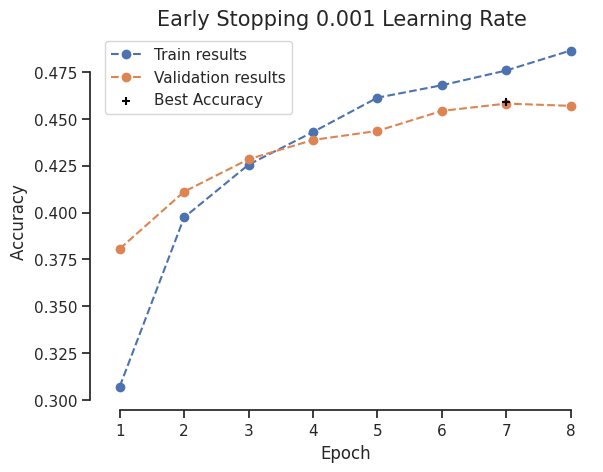

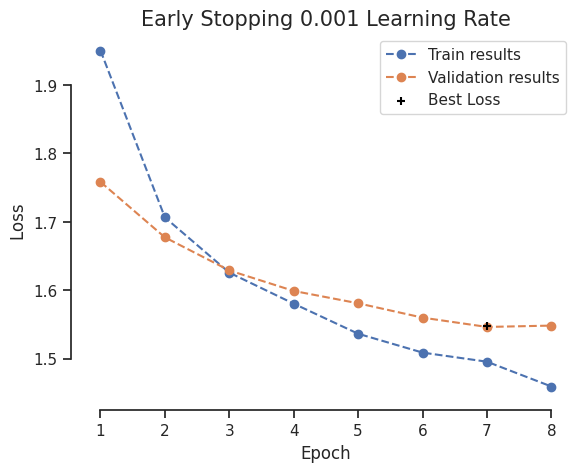

In [ ]:
plot(label = 'Accuracy ' , train_results = train_accs, val_results = val_accs , title = f'Early Stopping {0.001} Learning Rate ', extra_pt = accs_best, extra_pt_label = 'Best Accuracy')
plot(label = 'Loss ' , train_results = train_losses, val_results = val_losses , title = f'Early Stopping {0.001} Learning Rate', extra_pt = loss_best, extra_pt_label = 'Best Loss')

#### TODO:
- Compare the training you just did with the one of the same model trained for 100 epochs. Did you reach best model performance? If so: why? If not: why not?
- Implement a patience functionality into `EarlyStopper`: stop model training, if validation accuracy did not increase for `patience` epochs. You are allowed to add more arguments to `EarlyStopper.__init__`.
- Do the same training as in the previous cell, starting training from scratch, but try different values for `patience` now. Did you end up with a model resulting in the best validation accuracy you have seen so far, but without training the full 100 epochs?

* It was almost reached, due to the fact that the model stops at validation loss stagnation or increase, but minimal patience (1) in this case didn't let the model evolve, as the increase in the loss may have been a random event or fluctuation.
* Yes

In [ ]:
####################
## YOUR CODE HERE ##
####################
patience_list = [1,2,3,4,5,6,7,8]
losses_p = []
acc_p = []
number_of_epochs = []
for patience_value in patience_list:

    stopper = EarlyStopper(verbose = True, patience = patience_value)
    model = MLP().to(device)
    optimizer = optim.Adam(lr= 0.001, params = model.parameters())
    loss_function = nn.CrossEntropyLoss().to(device)

    # Training
    train_losses, val_losses, train_accs, val_accs, confusion_matrix = run_training(
    model=model,
    optimizer=optimizer,
    loss_function=loss_function,
    device=device,
    num_epochs=100,
    train_dataloader=trainloader,
    val_dataloader=valloader,
    verbose=True,
    early_stopper = stopper)

    number_of_epochs.append(len(val_losses))
    best_acc_index = int(np.argmax(val_accs))
    losses_p.append(float(val_losses[best_acc_index]))
    acc_p.append(float(np.max(val_accs)))

 New Best Accuracy Reached: 0.3897 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3897
 New Best Accuracy Reached: 0.4187 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4187
 New Best Accuracy Reached: 0.431 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.431
 New Best Accuracy Reached: 0.4403 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4403
 New Best Accuracy Reached: 0.4497 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4497
 New Best Accuracy Reached: 0.4554 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4554
 New Best Accuracy Reached: 0.4565 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4565
 New Best Accuracy Reached: 0.4616 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4616
 New Best 

 New Best Accuracy Reached: 0.3691 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3691
 New Best Accuracy Reached: 0.4063 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4063
 New Best Accuracy Reached: 0.4336 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4336
 New Best Accuracy Reached: 0.4398 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4398
 New Best Accuracy Reached: 0.4537 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4537
 New Best Accuracy Reached: 0.4545 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4545
 New Best Accuracy Reached: 0.4654 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4654
Early Stopping Counter: 1 / 2
Early Stopping Counter: 2 / 2
Early Stopping Triggered
Model Loaded from Checkpoint with Accuracy: 0.4

 New Best Accuracy Reached: 0.3822 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3822
 New Best Accuracy Reached: 0.415 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.415
 New Best Accuracy Reached: 0.4305 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4305
 New Best Accuracy Reached: 0.4445 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4445
 New Best Accuracy Reached: 0.4511 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4511
 New Best Accuracy Reached: 0.4513 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4513
 New Best Accuracy Reached: 0.4588 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4588
 New Best Accuracy Reached: 0.4607 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4607
 New Best 

 New Best Accuracy Reached: 0.3645 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3645
 New Best Accuracy Reached: 0.4142 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4142
 New Best Accuracy Reached: 0.4296 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4296
 New Best Accuracy Reached: 0.44 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.44
 New Best Accuracy Reached: 0.449 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.449
 New Best Accuracy Reached: 0.4496 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4496
 New Best Accuracy Reached: 0.4552 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4552
 New Best Accuracy Reached: 0.4572 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4572
 New Best Accu

 New Best Accuracy Reached: 0.3735 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3735
 New Best Accuracy Reached: 0.4119 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4119
 New Best Accuracy Reached: 0.4325 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4325
 New Best Accuracy Reached: 0.4462 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4462
 New Best Accuracy Reached: 0.4509 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4509
 New Best Accuracy Reached: 0.4555 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4555
Early Stopping Counter: 1 / 5
 New Best Accuracy Reached: 0.4622 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4622
 New Best Accuracy Reached: 0.4644 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validatio

 New Best Accuracy Reached: 0.3802 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3802
 New Best Accuracy Reached: 0.407 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.407
 New Best Accuracy Reached: 0.4191 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4191
 New Best Accuracy Reached: 0.434 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.434
 New Best Accuracy Reached: 0.4388 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4388
 New Best Accuracy Reached: 0.4475 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4475
 New Best Accuracy Reached: 0.4518 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4518
 New Best Accuracy Reached: 0.4547 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4547
 New Best Ac

 New Best Accuracy Reached: 0.3744 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3744
 New Best Accuracy Reached: 0.4133 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4133
 New Best Accuracy Reached: 0.4247 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4247
 New Best Accuracy Reached: 0.4437 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4437
 New Best Accuracy Reached: 0.4457 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4457
 New Best Accuracy Reached: 0.4512 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4512
Early Stopping Counter: 1 / 7
 New Best Accuracy Reached: 0.4568 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4568
 New Best Accuracy Reached: 0.4625 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validatio

 New Best Accuracy Reached: 0.3688 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3688
 New Best Accuracy Reached: 0.4146 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4146
 New Best Accuracy Reached: 0.4313 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4313
 New Best Accuracy Reached: 0.4409 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4409
 New Best Accuracy Reached: 0.4503 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4503
 New Best Accuracy Reached: 0.4592 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4592
 New Best Accuracy Reached: 0.4632 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4632
 New Best Accuracy Reached: 0.4675 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4675
Early St

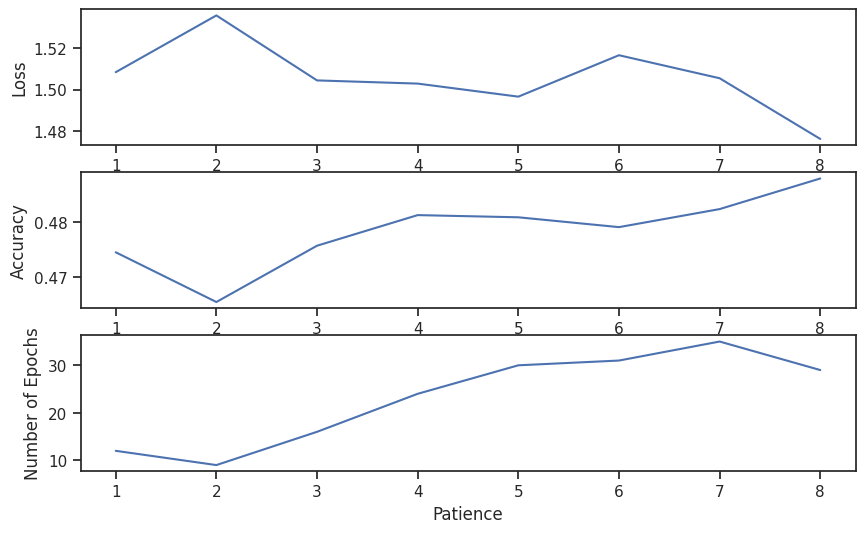

In [ ]:
fig,ax = plt.subplots(3,1,figsize=(10,6))
ax[0].plot(patience_list, losses_p, label = 'Validation Loss')
ax[0].set_xlabel('Patience')
ax[0].set_ylabel('Loss')

ax[1].plot(patience_list, acc_p, label= 'Validation Accuracy')
ax[1].set_xlabel('Patience')
ax[1].set_ylabel('Accuracy')

ax[2].plot(patience_list, number_of_epochs, label= 'Number of Epochs')
ax[2].set_xlabel('Patience')
ax[2].set_ylabel('Number of Epochs')

plt.show()

## Which learning rate is best?

Now that we have a learning strategy that works well, let us explore the effect of the learning rate on training and model performance.

#### TODO:
- Run training again as above, but with learning rate decreased by one order of magnitude, i.e. `lr = 1e-3`
- Run training again as above, but now with even smaller learning rate, `lr = 1e-4`
- What do you observe in terms of model accuracy? How long did it take to train these models? Which learning rate would you choose for any subsequent experiments you could do?

In [ ]:
lr = 1e-3

####################
## YOUR CODE HERE ##
####################

start_time = time.time()
stopper = EarlyStopper(verbose = True)
model = MLP().to(device)
optimizer = optim.Adam(lr= lr, params = model.parameters())
loss_function = nn.CrossEntropyLoss().to(device)
train_losses, val_losses, train_accs, val_accs, confusion_matrix = run_training(
    model=model,
    optimizer=optimizer,
    loss_function=loss_function,
    device=device,
    num_epochs=100,
    train_dataloader=trainloader,
    val_dataloader=valloader,
    verbose=True,
    early_stopper = stopper)

end_time = time.time()

 New Best Accuracy Reached: 0.3774 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3774
 New Best Accuracy Reached: 0.419 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.419
 New Best Accuracy Reached: 0.4302 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4302
 New Best Accuracy Reached: 0.4423 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4423
 New Best Accuracy Reached: 0.4549 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4549
 New Best Accuracy Reached: 0.4552 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4552
 New Best Accuracy Reached: 0.4593 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4593
 New Best Accuracy Reached: 0.4643 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4643
 New Best 

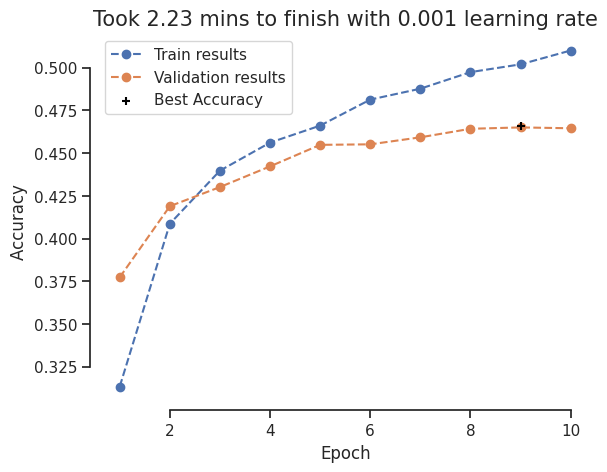

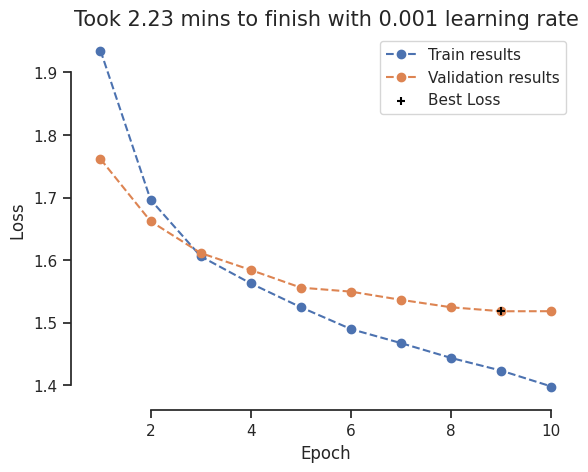

In [ ]:
loss_best = (int(np.argmin(val_losses)) +1  , np.min(val_losses) )
accs_best = (int(np.argmax(val_accs))  +1 , np.max(val_accs))
elapsed_mins = (end_time - start_time)/60
title = f"Took {elapsed_mins:.2f} mins to finish with {lr} learning rate"
plot(label = 'Accuracy ' , train_results = train_accs, val_results = val_accs , title = title, extra_pt = accs_best, extra_pt_label = 'Best Accuracy')
plot(label = 'Loss ' , train_results = train_losses, val_results = val_losses , title = title, extra_pt = loss_best, extra_pt_label = 'Best Loss')

In [ ]:
lr = 1e-4

####################
## YOUR CODE HERE ##
####################

start_time = time.time()
stopper = EarlyStopper(verbose = True)
model = MLP().to(device)
optimizer = optim.Adam(lr= lr, params = model.parameters())
loss_function = nn.CrossEntropyLoss().to(device)
train_losses, val_losses, train_accs, val_accs, confusion_matrix = run_training(
    model=model,
    optimizer=optimizer,
    loss_function=loss_function,
    device=device,
    num_epochs=100,
    train_dataloader=trainloader,
    val_dataloader=valloader,
    verbose=True,
    early_stopper = stopper)

end_time = time.time()

 New Best Accuracy Reached: 0.2535 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.2535
 New Best Accuracy Reached: 0.3251 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3251
 New Best Accuracy Reached: 0.3505 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3505
 New Best Accuracy Reached: 0.3673 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3673
 New Best Accuracy Reached: 0.3813 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3813
 New Best Accuracy Reached: 0.3917 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3917
 New Best Accuracy Reached: 0.4012 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4012
 New Best Accuracy Reached: 0.4095 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4095
 New Bes

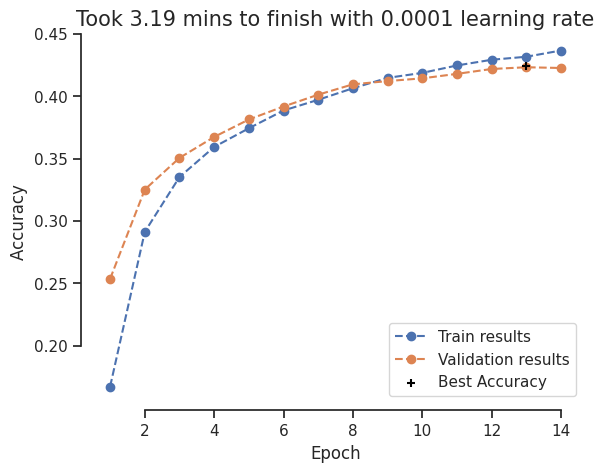

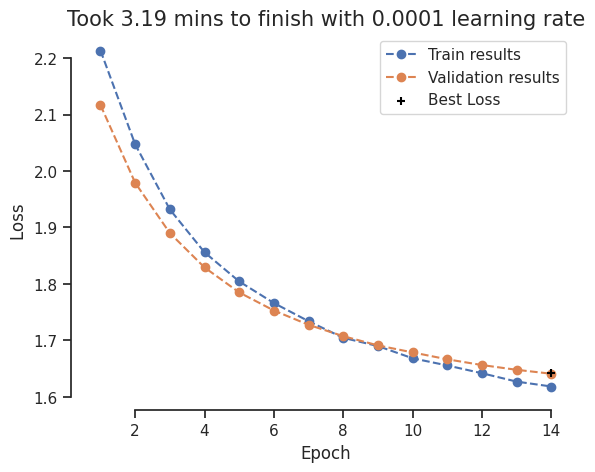

In [ ]:
loss_best = (int(np.argmin(val_losses)) +1  , np.min(val_losses) )
accs_best = (int(np.argmax(val_accs))  +1 , np.max(val_accs))
elapsed_mins = (end_time - start_time)/60
title = f"Took {elapsed_mins:.2f} mins to finish with {lr} learning rate"
plot(label = 'Accuracy ' , train_results = train_accs, val_results = val_accs , title = title, extra_pt = accs_best, extra_pt_label = 'Best Accuracy')
plot(label = 'Loss ' , train_results = train_losses, val_results = val_losses , title = title, extra_pt = loss_best, extra_pt_label = 'Best Loss')

# What about the architecture?

How does architecture affect predictive performance?

#### TODO:
In the following, try to improve model performance by varying
- number of  hidden units
- number of layers

These parameters are called hyper-parameters, since they are excluded from model optimization. Instead, we have to set them by hand and explore them to find a model with good predictive accuracy.

Vary only one hyper-parameter at a time. If you would vary multiple parameters at the same time, it would be harder for you to see the impact that each parameter has.

In [ ]:
# number of hidden units

####################
## YOUR CODE HERE ##
####################
n_units = np.arange(1,11) * 10
validation_loss = []
validation_accuracy = []

for neuron in n_units:

    stopper = EarlyStopper(verbose = True)
    model = MLP(num_hidden_units = neuron).to(device)
    optimizer = optim.Adam(lr= 1e-3, params = model.parameters())
    loss_function = nn.CrossEntropyLoss().to(device)

    train_losses, val_losses, train_accs, val_accs, confusion_matrix = run_training(
        model=model,
        optimizer=optimizer,
        loss_function=loss_function,
        device=device,
        num_epochs=100,
        train_dataloader=trainloader,
        val_dataloader=valloader,
        verbose=True,
        early_stopper = stopper)

    validation_loss.append(np.min(val_losses))
    validation_accuracy.append(np.max(val_accs))



 New Best Accuracy Reached: 0.2283 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.2283
 New Best Accuracy Reached: 0.2647 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.2647
 New Best Accuracy Reached: 0.2973 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.2973
 New Best Accuracy Reached: 0.3198 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3198
 New Best Accuracy Reached: 0.3405 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3405
 New Best Accuracy Reached: 0.3569 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3569
 New Best Accuracy Reached: 0.37 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.37
 New Best Accuracy Reached: 0.3719 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3719
 New Best Ac

 New Best Accuracy Reached: 0.351 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.351
 New Best Accuracy Reached: 0.3917 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3917
 New Best Accuracy Reached: 0.4046 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4046
 New Best Accuracy Reached: 0.4184 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4184
 New Best Accuracy Reached: 0.4323 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4323
 New Best Accuracy Reached: 0.4337 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4337
 New Best Accuracy Reached: 0.4355 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4355
 New Best Accuracy Reached: 0.4432 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4432
 New Best 

 New Best Accuracy Reached: 0.3814 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3814
 New Best Accuracy Reached: 0.4172 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4172
 New Best Accuracy Reached: 0.4362 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4362
 New Best Accuracy Reached: 0.4389 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4389
 New Best Accuracy Reached: 0.4436 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4436
 New Best Accuracy Reached: 0.4527 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4527
 New Best Accuracy Reached: 0.4555 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4555
 New Best Accuracy Reached: 0.4618 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4618
 New Bes

 New Best Accuracy Reached: 0.3954 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3954
 New Best Accuracy Reached: 0.4336 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4336
 New Best Accuracy Reached: 0.4382 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4382
 New Best Accuracy Reached: 0.4533 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4533
 New Best Accuracy Reached: 0.4642 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4642
 New Best Accuracy Reached: 0.4655 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4655
 New Best Accuracy Reached: 0.4743 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4743
 New Best Accuracy Reached: 0.4815 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4815
 New Bes

 New Best Accuracy Reached: 0.3976 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3976
 New Best Accuracy Reached: 0.4399 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4399
 New Best Accuracy Reached: 0.4544 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4544
 New Best Accuracy Reached: 0.4631 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4631
 New Best Accuracy Reached: 0.4717 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4717
 New Best Accuracy Reached: 0.4729 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4729
 New Best Accuracy Reached: 0.4767 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4767
 New Best Accuracy Reached: 0.4844 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4844
 New Bes

 New Best Accuracy Reached: 0.4047 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4047
 New Best Accuracy Reached: 0.4405 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4405
 New Best Accuracy Reached: 0.4529 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4529
 New Best Accuracy Reached: 0.4601 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4601
 New Best Accuracy Reached: 0.4777 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4777
 New Best Accuracy Reached: 0.4806 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4806
 New Best Accuracy Reached: 0.483 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.483
 New Best Accuracy Reached: 0.4939 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4939
 New Best 

 New Best Accuracy Reached: 0.4069 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4069
 New Best Accuracy Reached: 0.44 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.44
 New Best Accuracy Reached: 0.4609 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4609
 New Best Accuracy Reached: 0.4753 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4753
 New Best Accuracy Reached: 0.4798 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4798
 New Best Accuracy Reached: 0.4817 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4817
 New Best Accuracy Reached: 0.4911 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4911
 New Best Accuracy Reached: 0.5007 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.5007
 New Best Ac

 New Best Accuracy Reached: 0.4131 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4131
 New Best Accuracy Reached: 0.4465 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4465
 New Best Accuracy Reached: 0.4678 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4678
 New Best Accuracy Reached: 0.4796 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4796
 New Best Accuracy Reached: 0.485 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.485
 New Best Accuracy Reached: 0.4868 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4868
 New Best Accuracy Reached: 0.4918 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4918
 New Best Accuracy Reached: 0.4991 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4991
 New Best 

 New Best Accuracy Reached: 0.4163 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4163
 New Best Accuracy Reached: 0.4575 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4575
 New Best Accuracy Reached: 0.4687 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4687
 New Best Accuracy Reached: 0.4759 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4759
 New Best Accuracy Reached: 0.4948 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4948
 New Best Accuracy Reached: 0.4979 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4979
Early Stopping Counter: 1 / 1
Early Stopping Triggered
Model Loaded from Checkpoint with Accuracy: 0.4979
Finished training after 91 seconds.


 New Best Accuracy Reached: 0.4257 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4257
 New Best Accuracy Reached: 0.4561 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4561
 New Best Accuracy Reached: 0.4653 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4653
 New Best Accuracy Reached: 0.482 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.482
 New Best Accuracy Reached: 0.491 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.491
 New Best Accuracy Reached: 0.4997 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4997
 New Best Accuracy Reached: 0.5002 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.5002
 New Best Accuracy Reached: 0.5102 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.5102
Early Stoppi

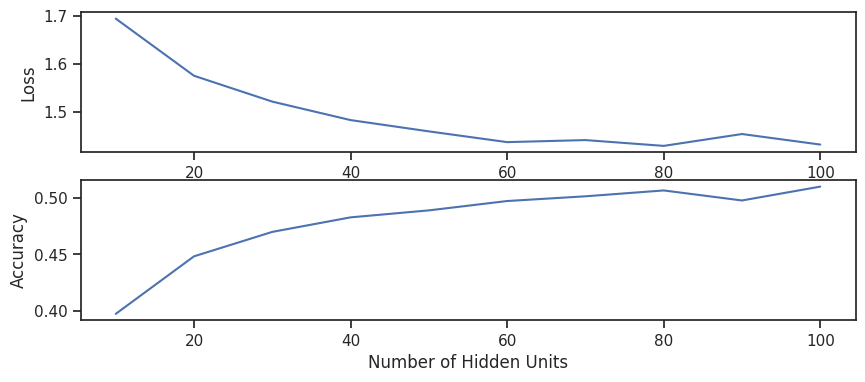

In [ ]:
fig,ax = plt.subplots(2,1,figsize= (10,4))
ax[0].plot(n_units, validation_loss, label = 'Validation Loss')
ax[0].set_ylabel('Loss')

ax[1].plot(n_units, validation_accuracy, label = 'Validation Accuracy')
ax[1].set_ylabel('Accuracy')

plt.xlabel('Number of Hidden Units')
plt.show()

In [ ]:
# number of layers

####################
## YOUR CODE HERE ##
####################
n_layers = np.arange(1,11)
validation_loss = []
validation_accuracy = []

for layers in n_layers:

    stopper = EarlyStopper(verbose = True)
    model = MLP(num_hidden_units = 30, num_hidden_layers = layers ).to(device)
    optimizer = optim.Adam(lr= 1e-3, params = model.parameters())
    loss_function = nn.CrossEntropyLoss().to(device)

    train_losses, val_losses, train_accs, val_accs, confusion_matrix = run_training(
        model=model,
        optimizer=optimizer,
        loss_function=loss_function,
        device=device,
        num_epochs=100,
        train_dataloader=trainloader,
        val_dataloader=valloader,
        verbose=True,
        early_stopper = stopper)

    validation_loss.append(np.min(val_losses))
    validation_accuracy.append(np.max(val_accs))

 New Best Accuracy Reached: 0.3781 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3781
 New Best Accuracy Reached: 0.4104 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4104
 New Best Accuracy Reached: 0.4298 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4298
 New Best Accuracy Reached: 0.4357 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4357
 New Best Accuracy Reached: 0.4515 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4515
 New Best Accuracy Reached: 0.4521 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4521
 New Best Accuracy Reached: 0.4558 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4558
 New Best Accuracy Reached: 0.465 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.465
Early Stop

 New Best Accuracy Reached: 0.3389 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3389
 New Best Accuracy Reached: 0.3869 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3869
 New Best Accuracy Reached: 0.4109 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4109
 New Best Accuracy Reached: 0.4254 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4254
 New Best Accuracy Reached: 0.4362 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4362
 New Best Accuracy Reached: 0.4439 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4439
 New Best Accuracy Reached: 0.4523 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4523
 New Best Accuracy Reached: 0.46 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.46
Early Stoppi

 New Best Accuracy Reached: 0.3034 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3034
 New Best Accuracy Reached: 0.3672 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3672
 New Best Accuracy Reached: 0.3972 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3972
 New Best Accuracy Reached: 0.4181 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4181
 New Best Accuracy Reached: 0.431 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.431
 New Best Accuracy Reached: 0.4436 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4436
 New Best Accuracy Reached: 0.4502 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4502
 New Best Accuracy Reached: 0.4517 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4517
 New Best 

 New Best Accuracy Reached: 0.2831 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.2831
 New Best Accuracy Reached: 0.3483 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3483
 New Best Accuracy Reached: 0.3861 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3861
 New Best Accuracy Reached: 0.4103 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4103
 New Best Accuracy Reached: 0.42 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.42
 New Best Accuracy Reached: 0.4277 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4277
 New Best Accuracy Reached: 0.4362 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4362
 New Best Accuracy Reached: 0.445 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.445
 New Best Accu

 New Best Accuracy Reached: 0.2295 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.2295
 New Best Accuracy Reached: 0.3246 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3246
 New Best Accuracy Reached: 0.3678 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3678
 New Best Accuracy Reached: 0.3845 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3845
 New Best Accuracy Reached: 0.4033 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4033
Early Stopping Counter: 1 / 1
Early Stopping Triggered
Model Loaded from Checkpoint with Accuracy: 0.4033
Finished training after 76 seconds.


 New Best Accuracy Reached: 0.2271 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.2271
 New Best Accuracy Reached: 0.2985 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.2985
 New Best Accuracy Reached: 0.3262 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3262
 New Best Accuracy Reached: 0.365 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.365
 New Best Accuracy Reached: 0.3795 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3795
 New Best Accuracy Reached: 0.394 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.394
 New Best Accuracy Reached: 0.4117 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4117
 New Best Accuracy Reached: 0.4168 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4168
 New Best Ac

 New Best Accuracy Reached: 0.1921 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.1921
 New Best Accuracy Reached: 0.2694 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.2694
 New Best Accuracy Reached: 0.3229 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3229
 New Best Accuracy Reached: 0.355 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.355
 New Best Accuracy Reached: 0.3738 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3738
 New Best Accuracy Reached: 0.3808 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3808
 New Best Accuracy Reached: 0.4 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4
 New Best Accuracy Reached: 0.4103 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4103
 New Best Accura

 New Best Accuracy Reached: 0.157 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.157
 New Best Accuracy Reached: 0.2082 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.2082
 New Best Accuracy Reached: 0.2314 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.2314
 New Best Accuracy Reached: 0.2688 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.2688
 New Best Accuracy Reached: 0.2728 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.2728
 New Best Accuracy Reached: 0.3183 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3183
 New Best Accuracy Reached: 0.3387 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3387
 New Best Accuracy Reached: 0.3431 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3431
 New Best 

 New Best Accuracy Reached: 0.1842 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.1842
 New Best Accuracy Reached: 0.208 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.208
 New Best Accuracy Reached: 0.2263 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.2263
 New Best Accuracy Reached: 0.2587 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.2587
 New Best Accuracy Reached: 0.2809 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.2809
 New Best Accuracy Reached: 0.3064 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3064
 New Best Accuracy Reached: 0.3304 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3304
 New Best Accuracy Reached: 0.3395 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3395
 New Best 

 New Best Accuracy Reached: 0.1664 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.1664
 New Best Accuracy Reached: 0.1978 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.1978
 New Best Accuracy Reached: 0.2161 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.2161
 New Best Accuracy Reached: 0.2312 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.2312
 New Best Accuracy Reached: 0.2699 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.2699
 New Best Accuracy Reached: 0.293 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.293
 New Best Accuracy Reached: 0.3011 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3011
 New Best Accuracy Reached: 0.3045 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3045
Early Stop

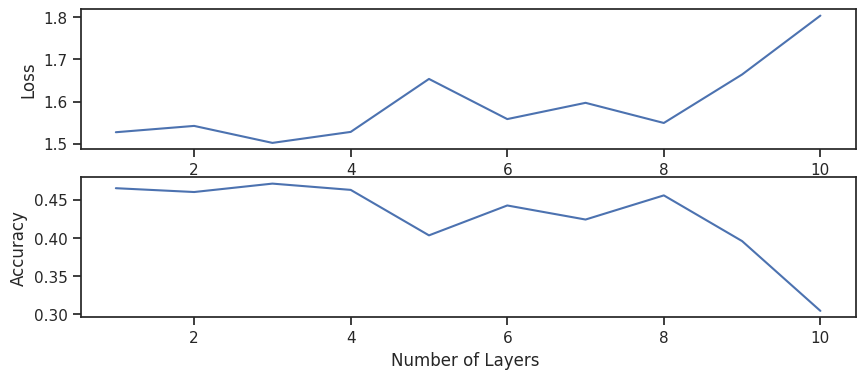

In [ ]:
fig,ax = plt.subplots(2,1,figsize= (10,4))
ax[0].plot(n_layers, validation_loss, label = 'Validation Loss')
ax[0].set_ylabel('Loss')

ax[1].plot(n_layers, validation_accuracy, label = 'Validation Accuracy')
ax[1].set_ylabel('Accuracy')

plt.xlabel('Number of Layers ')
plt.show()

#### Questions
- How good do you get?
- Which hyper-parameter makes the largest difference?
- Does it always help to make your model bigger (i.e. wider / deeper)? Why not?



**Your answers:**
- Number of hidden units made the biggest difference with 51% accuracy on 100 units.
- It does not always help as in this case only the number of hidden units made a positive difference, but the number of layers actually made the performance worse.

Now, here are more TODO's, questions and a little challenge for you:

#### TODO:
- If you choose your best values for number hidden units, number of layers and activation function that you determined by varying them independently above: Does performance improve? Why?
- Vary all of the parameters at the same time to maximize the predictive performance of your model. How good do you get?
    - When creating the exercise, I got a validation accuracy of 57%
    - Surpassing 50% val. acc. should be possible for you

In [ ]:
# Your best model:

####################
## YOUR CODE HERE ##
####################
stopper = EarlyStopper(verbose = True,patience = 8) # Best patience
model = MLP(num_hidden_units = 100, num_hidden_layers = 3).to(device) # Best Hidden Layers, Hidden Units
optimizer = optim.Adam(lr= 1e-3, params = model.parameters())
loss_function = nn.CrossEntropyLoss().to(device)
train_losses, val_losses, train_accs, val_accs, confusion_matrix = run_training(
    model=model,
    optimizer=optimizer,
    loss_function=loss_function,
    device=device,
    num_epochs=100,
    train_dataloader=trainloader,
    val_dataloader=valloader,
    verbose=True,
    early_stopper = stopper)

 New Best Accuracy Reached: 0.381 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.381
 New Best Accuracy Reached: 0.4312 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4312
 New Best Accuracy Reached: 0.4496 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4496
 New Best Accuracy Reached: 0.4735 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4735
 New Best Accuracy Reached: 0.48 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.48
 New Best Accuracy Reached: 0.4916 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4916
 New Best Accuracy Reached: 0.499 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.499
Early Stopping Counter: 1 / 8
 New Best Accuracy Reached: 0.5048 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accura

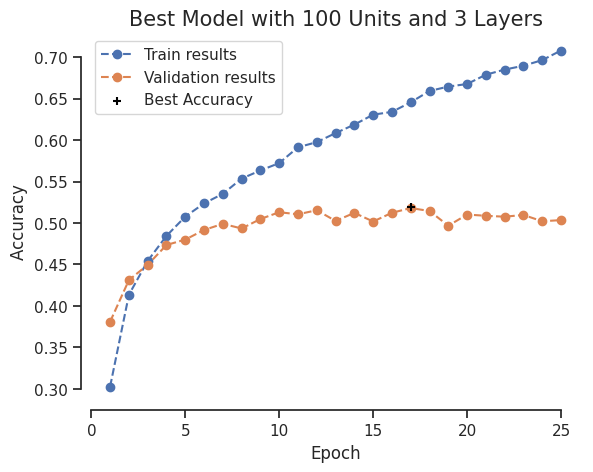

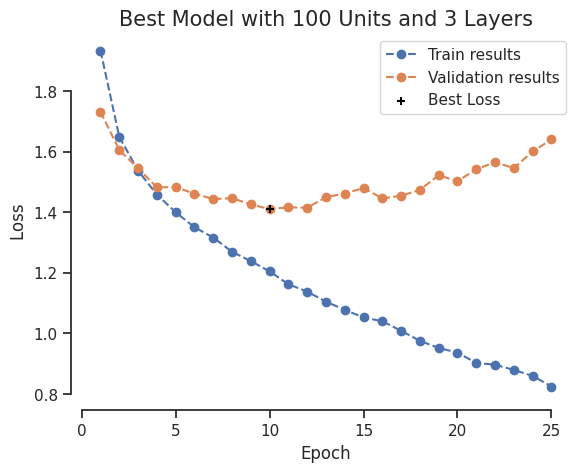

In [ ]:
loss_best = (int(np.argmin(val_losses)) +1  , np.min(val_losses) )
accs_best = (int(np.argmax(val_accs))  +1 , np.max(val_accs))

title = f"Best Model with 100 Units and 3 Layers"
plot(label = 'Accuracy ' , train_results = train_accs, val_results = val_accs , title = title, extra_pt = accs_best, extra_pt_label = 'Best Accuracy')
plot(label = 'Loss ' , train_results = train_losses, val_results = val_losses , title = title, extra_pt = loss_best, extra_pt_label = 'Best Loss')

#### Questions:
- If you train the same model multiple times from scratch: do you get the same performance? Are the models you trained above comparable then?
- What could we do about this?
    - *Hint:* there are actually multiple answers to this question.
    - One could be to change model training and evaluation. How?
    - The other could be to use a more sophisticated analysis. How?

# Evaluate your best model on test set, once!

When doing a study, at the very end right before writing up your paper, you evaluate the best model you chose on the test set. This is the performance value you will report to the public.

#### TODO:
- What is the accuracy of the best model you found on the test set?
- Plot the confusion matrix, too!

In [ ]:
def test(test_loader, model, device):
    """Compute accuracy and confusion matrix on test set.

    Args:
        test_loader (DataLoader): torch DataLoader of test set
        model (nn.Module): Model to evaluate on test set
        device (torch.device): Device to use

    Returns:
        float, torch.Tensor shape (10,10): Returns model accuracy on test set
            (percent classified correctly) and confusion matrix
    """
    ####################
    ## YOUR CODE HERE ##
    ####################

    correct = 0
    total = 0
    confusion_matrix = torch.zeros(10, 10)
    model.eval()

    with torch.no_grad():

        for x, y in test_loader:

            x = x.to(device)
            y = y.to(device)
            # Forward pass
            y_pred = model(x)
            # Correct Indices
            correct += (y == y_pred.argmax(dim=1)).sum().item()
            total += len(y)

            for (y_true, y_p) in zip(y, y_pred.argmax(dim=1)):
                confusion_matrix[int(y_true), int(y_p)] +=1


    return  accuracy(correct, total)*100, confusion_matrix


*Hint:* Use sklearn to create the confusion matrix ([link](https://scikit-learn.org/1.5/modules/generated/sklearn.metrics.confusion_matrix.html))

In [ ]:
# The accuracy and confusion matrix

####################
## YOUR CODE HERE ##
####################
acc, confusion_matrix = test(testloader, model, device)
confusion_matrix = confusion_matrix.numpy().astype(int)
print(f'Attained Accuracy on Test Set is: {acc}%')

Attained Accuracy on Test Set is: 51.99%


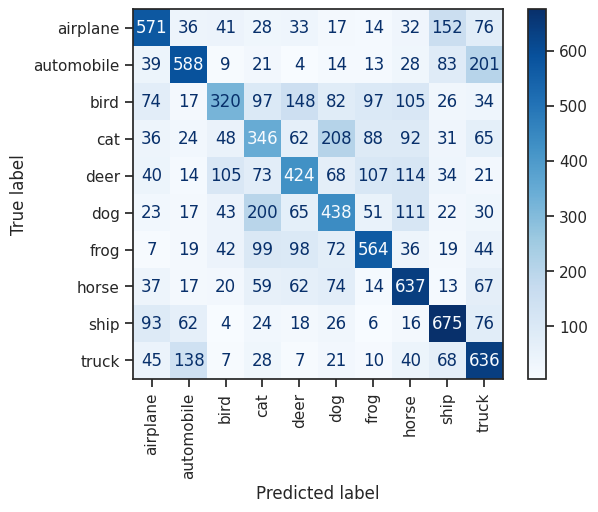

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=classes)
disp.plot(include_values=True, cmap='Blues', xticks_rotation='vertical', colorbar=True)
plt.show()

#### Questions:
- On which classes is your model's prediction poor?
- Is the test accuracy of your model as good as the validation accuracy?
- If those values are different: How can you explain the difference?
- Why should you never use test set performance when trying out different hyper-parameters and architectures?

## How about the optimizer? _(Optional)_

_This task is optional, you do not need to solve it_

Now let's check out what difference it makes to use different optimizers in the learning strategy and what effect it has on the performance.

#### TODO *(Optional)*:

- Run training of the same model used above with
    - different optimizers (_hint_ - https://pytorch.org/docs/stable/optim.html)
- Compare your training results of all the different optimizer settings from above.
- What is your observation while using different optimizers? What is the respective impact on the model performance?

In [ ]:
###############################
## YOUR CODE HERE - OPTIONAL ##
###############################
torch.manual_seed(42) # Setting a Seed for Fair Comparison

opt_factories = [
    ("SGD",    lambda p: optim.SGD(p, lr=1e-1)),
    ("Adam",   lambda p: optim.Adam(p, lr=1e-3)),
    ("AdamW",  lambda p: optim.AdamW(p, lr=1e-3)),
    ("RMSprop",lambda p: optim.RMSprop(p, lr=1e-3)),
    ("Adagrad",lambda p: optim.Adagrad(p, lr=1e-2)),
]

results = []
for name, make_opt in opt_factories:

    stopper = EarlyStopper(verbose = True,patience = 8) # Best patience
    model = MLP(num_hidden_units = 100, num_hidden_layers = 3).to(device) # Best Hidden Layers, Hidden Units

    optimizer = make_opt(model.parameters())

    loss_function = nn.CrossEntropyLoss().to(device)
    train_losses, val_losses, train_accs, val_accs, confusion_matrix = run_training(
        model=model,
        optimizer=optimizer,
        loss_function=loss_function,
        device=device,
        num_epochs=100,
        train_dataloader=trainloader,
        val_dataloader=valloader,
        verbose=True,
        early_stopper = stopper)


    results.append({
        "optimizer": name,
        "best_val_loss": float(np.min(val_losses)),
        "best_val_acc": float(np.max(val_accs))
    })

 New Best Accuracy Reached: 0.1586 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.1586
 New Best Accuracy Reached: 0.2339 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.2339
 New Best Accuracy Reached: 0.267 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.267
 New Best Accuracy Reached: 0.2929 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.2929
 New Best Accuracy Reached: 0.315 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.315
 New Best Accuracy Reached: 0.3371 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3371
 New Best Accuracy Reached: 0.3609 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3609
 New Best Accuracy Reached: 0.3857 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3857
Early Stoppi

 New Best Accuracy Reached: 0.3888 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3888
 New Best Accuracy Reached: 0.4241 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4241
 New Best Accuracy Reached: 0.4575 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4575
 New Best Accuracy Reached: 0.4647 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4647
 New Best Accuracy Reached: 0.4813 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4813
 New Best Accuracy Reached: 0.4913 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4913
 New Best Accuracy Reached: 0.5024 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.5024
Early Stopping Counter: 1 / 8
 New Best Accuracy Reached: 0.5142 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validatio

 New Best Accuracy Reached: 0.3961 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3961
 New Best Accuracy Reached: 0.428 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.428
 New Best Accuracy Reached: 0.4573 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4573
 New Best Accuracy Reached: 0.4849 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4849
Early Stopping Counter: 1 / 8
 New Best Accuracy Reached: 0.4961 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4961
Early Stopping Counter: 1 / 8
 New Best Accuracy Reached: 0.5111 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.5111
Early Stopping Counter: 1 / 8
Early Stopping Counter: 2 / 8
Early Stopping Counter: 3 / 8
 New Best Accuracy Reached: 0.5188 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accu

 New Best Accuracy Reached: 0.2821 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.2821
 New Best Accuracy Reached: 0.3182 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3182
 New Best Accuracy Reached: 0.3775 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3775
 New Best Accuracy Reached: 0.3976 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3976
Early Stopping Counter: 1 / 8
Early Stopping Counter: 2 / 8
Early Stopping Counter: 3 / 8
 New Best Accuracy Reached: 0.444 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.444
Early Stopping Counter: 1 / 8
Early Stopping Counter: 2 / 8
 New Best Accuracy Reached: 0.4508 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4508
Early Stopping Counter: 1 / 8
Early Stopping Counter: 2 / 8
Early Stopping Counter: 3 / 8
Early Stopping Cou

 New Best Accuracy Reached: 0.3084 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3084
 New Best Accuracy Reached: 0.3786 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3786
Early Stopping Counter: 1 / 8
 New Best Accuracy Reached: 0.4257 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4257
 New Best Accuracy Reached: 0.428 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.428
Early Stopping Counter: 1 / 8
Early Stopping Counter: 2 / 8
Early Stopping Counter: 3 / 8
Early Stopping Counter: 4 / 8
 New Best Accuracy Reached: 0.467 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.467
Early Stopping Counter: 1 / 8
Early Stopping Counter: 2 / 8
Early Stopping Counter: 3 / 8
Early Stopping Counter: 4 / 8
Early Stopping Counter: 5 / 8
 New Best Accuracy Reached: 0.4868 
Model Saved at Path: checkpoint.pt
Model Saved W

In [ ]:
print(results)

[{'optimizer': 'SGD', 'best_val_loss': 1.5481055498123169, 'best_val_acc': 0.4586}, {'optimizer': 'Adam', 'best_val_loss': 1.4041810989379884, 'best_val_acc': 0.5188}, {'optimizer': 'AdamW', 'best_val_loss': 1.399848997592926, 'best_val_acc': 0.5285}, {'optimizer': 'RMSprop', 'best_val_loss': 1.5948631525039674, 'best_val_acc': 0.454}, {'optimizer': 'Adagrad', 'best_val_loss': 1.5204961895942688, 'best_val_acc': 0.4868}]


## Explore batch size *(Optional)*

*This task is optional, you do not need to solve it*

Let us explore even more model and training parameters. In this section, we will see the impact of batch size on training. Let us use a learning rate of $10^{-3}$ from now on.


#### TODO *(Optional)*:
- Run training of the same model used above with
    - batch size 1 for **one epoch**
    - batch size 512 for 100 epochs, using early stopping with patience 10
- Compare your training results of all three batch sizes you have trained, i.e. batch size 1, 512 and 1024 (from above)
- Was it smart to set batch size to 1?
- How long (in terms of computing time) do your models need to train for the different batch sizes? (You could even measure this with python, using the `time` package)
- What is the impact on model performance?

*Hint*: You have to initialize new data loaders, as they provide you with batches during training.

In [ ]:
# Batch size 1

###############################
## YOUR CODE HERE - OPTIONAL ##
###############################

trainloader, valloader, testloader = init_data_loaders(trainset, valset, testset, batch_size = 1)

model = MLP(num_hidden_units = 100, num_hidden_layers = 3).to(device) # Best Hidden Layers, Hidden Units
optimizer = optim.Adam(lr= 1e-3, params = model.parameters())
loss_function = nn.CrossEntropyLoss().to(device)
train_losses, val_losses, train_accs, val_accs, confusion_matrix = run_training(
    model=model,
    optimizer=optimizer,
    loss_function=loss_function,
    device=device,
    num_epochs=1,
    train_dataloader=trainloader,
    val_dataloader=valloader,
    verbose=True,
    early_stopper = None)



Finished training after 182 seconds.


In [ ]:
# Batch size 512


###############################
## YOUR CODE HERE - OPTIONAL ##
###############################
start_time = time.time()

trainloader, valloader, testloader = init_data_loaders(trainset, valset, testset, batch_size = 512)

stopper = EarlyStopper(verbose = True,patience = 10)
model = MLP(num_hidden_units = 100, num_hidden_layers = 3).to(device) # Best Hidden Layers, Hidden Units
optimizer = optim.Adam(lr= 1e-3, params = model.parameters())
loss_function = nn.CrossEntropyLoss().to(device)
train_losses, val_losses, train_accs, val_accs, confusion_matrix = run_training(
    model=model,
    optimizer=optimizer,
    loss_function=loss_function,
    device=device,
    num_epochs=100,
    train_dataloader=trainloader,
    val_dataloader=valloader,
    verbose=True,
    early_stopper = stopper)

end_time = time.time()
print('Time taken to train the model' ,end_time-start_time)

 New Best Accuracy Reached: 0.4179 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4179
 New Best Accuracy Reached: 0.4549 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4549
 New Best Accuracy Reached: 0.4768 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4768
 New Best Accuracy Reached: 0.4929 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4929
 New Best Accuracy Reached: 0.502 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.502
Early Stopping Counter: 1 / 10
 New Best Accuracy Reached: 0.5145 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.5145
Early Stopping Counter: 1 / 10
Early Stopping Counter: 2 / 10
Early Stopping Counter: 3 / 10
Early Stopping Counter: 4 / 10
 New Best Accuracy Reached: 0.5146 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation

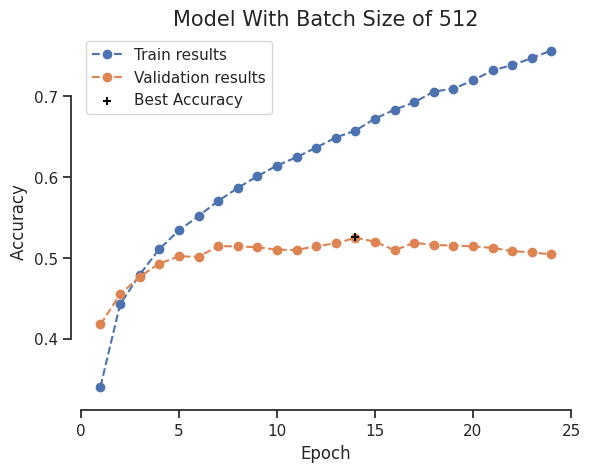

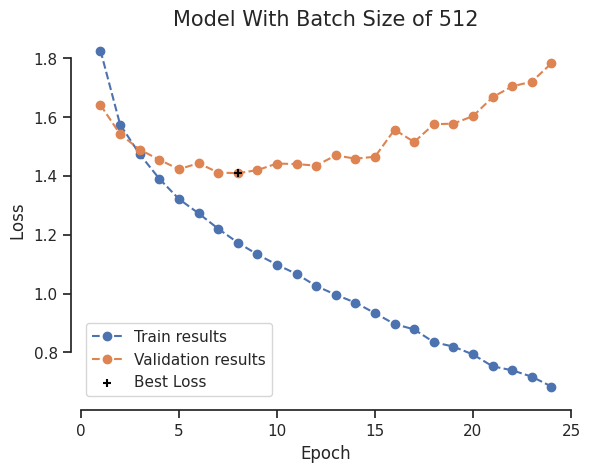

In [ ]:
loss_best = (int(np.argmin(val_losses)) +1  , np.min(val_losses) )
accs_best = (int(np.argmax(val_accs))  +1 , np.max(val_accs))

title = f"Model With Batch Size of 512"
plot(label = 'Accuracy ' , train_results = train_accs, val_results = val_accs , title = title, extra_pt = accs_best, extra_pt_label = 'Best Accuracy')
plot(label = 'Loss ' , train_results = train_losses, val_results = val_losses , title = title, extra_pt = loss_best, extra_pt_label = 'Best Loss')

(OPTIONAL) You should evaluate on the test set with the optional solutions here (and see if they lead to performance gain).

In addition to the submissions, every member of your group should be prepared to present the exercise in the tutorials. You don't need to present the optional exercises

## Explore Activation Function _(Optional)_

*This task is optional, you do not need to solve it*

### TODO _(Optional)_:

Let's change activation function used (e.g. see [here](https://pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity))
- Run training of the same model used above with a new activation function
- Compare your training results

In [ ]:
###############################
## YOUR CODE HERE - OPTIONAL ##
###############################
start_time = time.time()

trainloader, valloader, testloader = init_data_loaders(trainset, valset, testset, batch_size = 512)

stopper = EarlyStopper(verbose = True,patience = 10)
model = MLP(num_hidden_units = 100, num_hidden_layers = 3, act_fn = nn.Tanh()).to(device) # Best Hidden Layers, Hidden Units
optimizer = optim.Adam(lr= 1e-3, params = model.parameters())
loss_function = nn.CrossEntropyLoss().to(device)
train_losses, val_losses, train_accs, val_accs, confusion_matrix = run_training(
    model=model,
    optimizer=optimizer,
    loss_function=loss_function,
    device=device,
    num_epochs=100,
    train_dataloader=trainloader,
    val_dataloader=valloader,
    verbose=True,
    early_stopper = stopper)

end_time = time.time()
print('Time taken to train the model' ,end_time-start_time)


 New Best Accuracy Reached: 0.3893 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.3893
 New Best Accuracy Reached: 0.4126 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4126
 New Best Accuracy Reached: 0.4239 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4239
 New Best Accuracy Reached: 0.4309 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4309
 New Best Accuracy Reached: 0.4321 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4321
 New Best Accuracy Reached: 0.4389 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4389
 New Best Accuracy Reached: 0.4406 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validation Accuracy of: 0.4406
Early Stopping Counter: 1 / 10
 New Best Accuracy Reached: 0.4462 
Model Saved at Path: checkpoint.pt
Model Saved With Best Validati

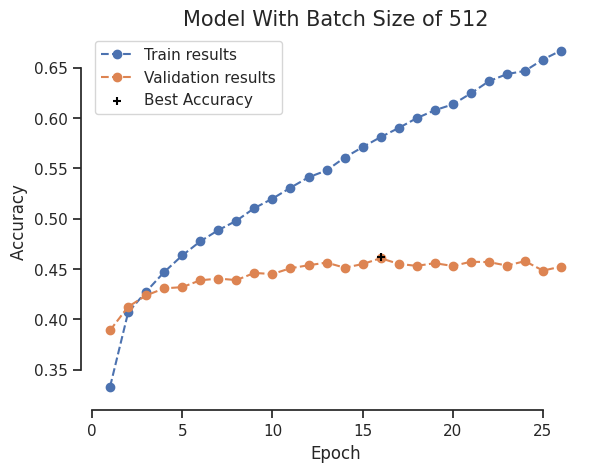

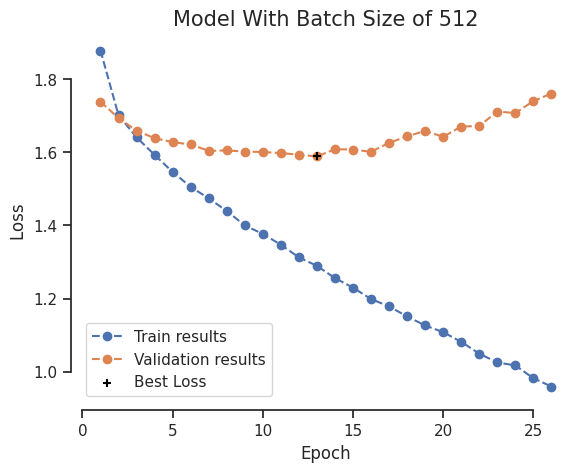

In [ ]:
loss_best = (int(np.argmin(val_losses)) +1  , np.min(val_losses) )
accs_best = (int(np.argmax(val_accs))  +1 , np.max(val_accs))

title = f"Model With Batch Size of 512"
plot(label = 'Accuracy ' , train_results = train_accs, val_results = val_accs , title = title, extra_pt = accs_best, extra_pt_label = 'Best Accuracy')
plot(label = 'Loss ' , train_results = train_losses, val_results = val_losses , title = title, extra_pt = loss_best, extra_pt_label = 'Best Loss')